# Darts bake-off — Ukraine weekly conflict counts

Compares a Darts model suite against the same **expanding-window walk-forward
CV** and **12-week hold-out** used by `src/pipeline.py` / `02_modeling_and_evaluation.ipynb`.

Target (Variant A): weekly GDELT conflict count (CAMEO 18/19) for Ukraine (`UP`),
direct 1–4 week horizons. The persistence baseline is known to be very strong
on this series; this notebook tests whether Darts statistical, tabular, and
neural models can beat it. Preference: **more interpretable is better**.

**Wave 1 — original bake-off**

| Group | Darts class | Notes |
|---|---|---|
| Baseline | `NaiveSeasonal(K=1)` | Last observed value (same idea as pipeline naive) |
| Baseline | `NaiveMovingAverage(4)` | Trailing 4-week mean |
| Statistical | `AutoARIMA(season_length=1)` | Non-seasonal AutoARIMA (statsforecast) |
| Statistical | `AutoTheta(season_length=1)` | Auto-Theta |
| Statistical | `AutoCES(season_length=1)` | Complex exponential smoothing |
| Tabular | `LinearRegressionModel` | Lags + past/future covariates, direct 4-step |
| Tabular | `LightGBMModel` | Same lags/covariates on **first differences**, then reconstruct the level |
| Neural | `NHiTSModel` | Small architecture; ~245 weekly points only |

**Wave 2 — more sophisticated, prefer interpretable** (sections 9–13)

| Group | Darts class | Why this one | Protocol |
|---|---|---|---|
| Statistical | `ExponentialSmoothing` (damped Holt, no yearly season) | Level + trend, fully readable | full CV |
| Statistical | `KalmanForecaster(dim_x=2)` | State-space level/trend + calendar controls | full CV |
| Tabular | Ridge (`SKLearnModel` + `StandardScaler`) | Same lags as linreg, but regularized & scaled | full CV |
| Tabular | `XGBModel` | Tree ensemble with gain importance | full CV |
| Tabular | `RandomForestModel` | Shallow forest, lag/covariate importances | full CV |
| Neural (linear) | `DLinearModel` | Trend/season split + linear map — readable weights | full CV |
| Neural (linear) | `NLinearModel` | Last-value normalization + linear (N-Linear paper) | full CV |
| Neural (interp.) | `NBEATSModel(generic_architecture=False)` | Explicit trend + seasonality stacks | last-12-fold CV |
| Transformer-like | `TFTModel` | Attention + **variable-selection weights** | last-12-fold CV |
| Transformer | `TransformerModel` | Vanilla encoder–decoder; least readable, included as a foil | last-12-fold CV |

Transformer-class models are fit only on the **last 12 CV folds** (longer train,
recent war regime) plus the 12-week hold-out. Full 44-fold CV on TFT/Transformer
would spend most of the time on the first year of the war where 52–80 training
weeks cannot support attention models. Hold-out is the apples-to-apples ranking
across every model.

Prerequisite: `data/processed/feature_panel.parquet` (from `01_eda.ipynb` or
`python -m src.pipeline`). Metrics/figures are written to `outputs/darts/`.

**Contents**
1. Setup & TimeSeries construction
2. Hold-out / CV split recap
3. Model factory
4. Walk-forward CV
5. Hold-out evaluation
6. Visualizations
7. Future 1–4 week forecast
8. Takeaways (wave 1)
9. Extended interpretable models (full CV)
10. Neural / transformer models
11. Interpretability
12. Combined ranking
13. Takeaways (wave 2)


In [1]:
import os
# Torch in this environment sees a CUDA runtime newer than the host driver.
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
warnings.filterwarnings("ignore")

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import (
    AutoARIMA,
    AutoCES,
    AutoTheta,
    LightGBMModel,
    LinearRegressionModel,
    NaiveMovingAverage,
    NaiveSeasonal,
    NHiTSModel,
)

from src.utils import load_config, repo_path, write_json
from src.validation.metrics import regression_report
from src.validation.walk_forward import generate_folds, split_holdout
from IPython.display import display

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
SEED = cfg["random_seed"]
HORIZONS = cfg["target"]["horizons"]
MAX_H = max(HORIZONS)
OUT_DIR = repo_path("outputs", "darts")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg["target"], cfg["validation"], str(OUT_DIR)


({'variant': 'A',
  'horizons': [1, 2, 3, 4],
  'strategy': 'direct',
  'escalation_rolling_window_weeks': 52,
  'escalation_zscore_k': 2.0},
 {'holdout_weeks': 12,
  'cv_initial_train_weeks': 52,
  'cv_step_weeks': 4,
  'min_test_weeks_per_fold': 4},
 '/home/romanrussia/Code_git/GDETL/outputs/darts')

## 1. Setup & TimeSeries construction

Darts builds its own lags, so we do **not** pass `conflict_count_lag*` /
rolling means as covariates. Calendar fields are **future covariates**
(known at the target week); GDELT tone, Google Trends, and ACLED totals are
**past covariates** (known at the origin week only).


In [2]:
feature_path = repo_path(cfg["data"]["weekly_panel_path"]).with_name("feature_panel.parquet")
raw = pd.read_parquet(feature_path)
raw["week_start"] = pd.to_datetime(raw["week_start"])
raw = raw.sort_values("week_start").reset_index(drop=True)

PAST_COLS = [
    "avg_goldstein", "avg_tone", "goldstein_volatility",
    "total_events_country", "news_volume_change_wow",
    "google_trends_score", "google_trends_change_wow",
    "weeks_since_major_spike",
    "acled_total_events", "acled_total_fatalities", "acled_events_change_wow",
]
for extra in (
    "acled_armed_clash_events",
    "acled_shelling_artillery_missile_attack_events",
    "acled_air_drone_strike_events",
):
    if extra in raw.columns:
        PAST_COLS.append(extra)
PAST_COLS = [c for c in PAST_COLS if c in raw.columns]
FUTURE_COLS = ["week_of_year", "month", "is_holiday"]

FREQ = "W-MON"
N_FUTURE_PAD = 8  # extra calendar weeks so predict(n=4) always has future covariates

indexed = raw.set_index("week_start")
target_pd = indexed["conflict_count"].astype(float)

past_pd = indexed[PAST_COLS].astype(float).replace([np.inf, -np.inf], np.nan)
past_pd = past_pd.ffill().bfill().fillna(0.0)

future_pd = indexed[FUTURE_COLS].astype(float).copy()
extra_idx = pd.date_range(indexed.index[-1] + pd.Timedelta(weeks=1), periods=N_FUTURE_PAD, freq=FREQ)
try:
    import holidays as pyholidays
    ua_holidays = pyholidays.country_holidays("UA")
except Exception:
    ua_holidays = None

extra_rows = []
for ts in extra_idx:
    is_hol = 0
    if ua_holidays is not None:
        is_hol = int(any((ts + pd.Timedelta(days=i)).date() in ua_holidays for i in range(7)))
    extra_rows.append({
        "week_of_year": float(ts.isocalendar().week),
        "month": float(ts.month),
        "is_holiday": float(is_hol),
    })
future_pd = pd.concat([future_pd, pd.DataFrame(extra_rows, index=extra_idx)])

series = TimeSeries.from_series(target_pd, freq=FREQ)
past_cov = TimeSeries.from_dataframe(past_pd, freq=FREQ)
future_cov = TimeSeries.from_dataframe(future_pd, freq=FREQ)
series_diff = series.diff()
past_cov_diff = past_cov[1:]  # align with first difference (starts one week later)

# Incomplete GDELT weeks must not be scored as targets (same mask as the pipeline).
incomplete_weeks = set(
    pd.to_datetime(raw.loc[raw["days_covered"].fillna(7) < 7, "week_start"]).dt.normalize()
)

print(f"panel: {len(raw)} weeks ({raw['week_start'].min().date()} .. {raw['week_start'].max().date()})")
print(f"target series: n={len(series)}, freq={series.freq}")
print(f"past covariates ({len(PAST_COLS)}): {PAST_COLS}")
print(f"incomplete GDELT weeks (masked targets): {len(incomplete_weeks)}")
series


panel: 245 weeks (2021-12-27 .. 2026-08-31)
target series: n=245, freq=<Week: weekday=0>
past covariates (14): ['avg_goldstein', 'avg_tone', 'goldstein_volatility', 'total_events_country', 'news_volume_change_wow', 'google_trends_score', 'google_trends_change_wow', 'weeks_since_major_spike', 'acled_total_events', 'acled_total_fatalities', 'acled_events_change_wow', 'acled_armed_clash_events', 'acled_shelling_artillery_missile_attack_events', 'acled_air_drone_strike_events']
incomplete GDELT weeks (masked targets): 7


,conflict_count
week_start,
2021-12-27,58.0
2022-01-03,292.0
2022-01-10,435.0
2022-01-17,841.0
2022-01-24,1259.0
...,...
2026-08-03,2192.0
2026-08-10,2055.0
2026-08-17,1930.0


## 2. Hold-out / CV split recap

Same rule as `src/validation/walk_forward.py`:

- Hold-out = last 12 **realized** weeks.
- CV pool origins are cut so that `origin + 4 weeks` is still before hold-out start
  (no model is fit on a row whose target lands in hold-out).
- Expanding window: `initial_train_weeks=52`, `step_weeks=4`.


CV pool:        230 origin weeks (2021-12-27 .. 2026-05-18)
Hold-out:       12 realized weeks, starting 2026-06-15
Walk-forward:   44 folds


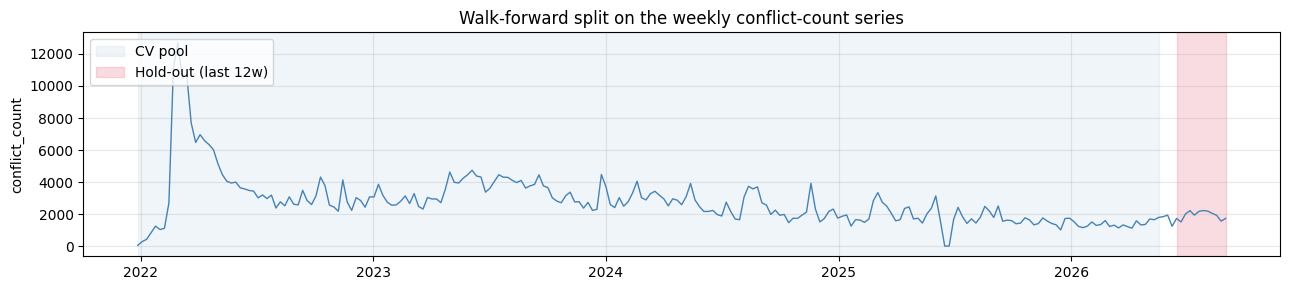

In [3]:
cv_pool, full_df, holdout_start, holdout_target_weeks = split_holdout(
    raw.assign(week_start=raw["week_start"].dt.date),
    cfg["validation"]["holdout_weeks"],
    MAX_H,
)
folds = generate_folds(
    len(cv_pool),
    cfg["validation"]["cv_initial_train_weeks"],
    cfg["validation"]["cv_step_weeks"],
    cfg["validation"]["min_test_weeks_per_fold"],
)
n_cv = len(cv_pool)
times = series.time_index
cv_end_time = times[n_cv - 1]
holdout_times = sorted(pd.to_datetime(list(holdout_target_weeks)))

print(f"CV pool:        {n_cv} origin weeks ({cv_pool['week_start'].min()} .. {cv_pool['week_start'].max()})")
print(f"Hold-out:       {len(holdout_target_weeks)} realized weeks, starting {holdout_start}")
print(f"Walk-forward:   {len(folds)} folds")

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(pd.to_datetime(raw["week_start"]), raw["conflict_count"], color="steelblue", lw=1)
ax.axvspan(times[0], cv_end_time, color="steelblue", alpha=0.08, label="CV pool")
ax.axvspan(holdout_start, raw["week_start"].max(), color="crimson", alpha=0.15, label="Hold-out (last 12w)")
ax.set_ylabel("conflict_count")
ax.set_title("Walk-forward split on the weekly conflict-count series")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "split_recap.png", dpi=130)
plt.show()


## 3. Model factory

- **Naive / MA**: refit at each origin (Darts local models do not take `series=` at `predict`).
- **AutoARIMA / AutoTheta / AutoCES**: fit once per fold on the training slice, then
  `predict(n=4, series=history_up_to_origin)` (transferable).
- **Linear / LightGBM / N-HiTS**: global models — fit once per fold, predict from each
  test origin using actual history up to that origin (same information set as pipeline XGBoost).
- **LightGBM-diff**: trained on `Δ conflict_count`; forecasts are cumulatively added back
  to the last observed level so the model only has to predict *changes*.


In [4]:
LAGS = [-1, -2, -4, -12]
LAGS_PAST = [-1, -2, -4]
LAGS_FUTURE = [0]  # calendar value at the predicted week

LOCAL_REFIT = {"naive_seasonal", "naive_ma4"}
STAT_TRANSFER = {"auto_arima", "auto_theta", "auto_ces"}
DIFF_MODELS = {"lgbm_diff"}
GLOBAL_LEVEL = {"linreg", "lgbm", "nhits"}


def make_models(seed: int = 42) -> dict:
    lgbm_kw = dict(
        lags=LAGS,
        lags_past_covariates=LAGS_PAST,
        lags_future_covariates=LAGS_FUTURE,
        output_chunk_length=MAX_H,
        multi_models=True,
        random_state=seed,
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=8,
        verbose=-1,
    )
    return {
        "naive_seasonal": NaiveSeasonal(K=1),
        "naive_ma4": NaiveMovingAverage(input_chunk_length=4),
        "auto_arima": AutoARIMA(season_length=1),
        "auto_theta": AutoTheta(season_length=1),
        "auto_ces": AutoCES(season_length=1),
        "linreg": LinearRegressionModel(
            lags=LAGS,
            lags_past_covariates=LAGS_PAST,
            lags_future_covariates=LAGS_FUTURE,
            output_chunk_length=MAX_H,
            multi_models=True,
        ),
        "lgbm": LightGBMModel(**lgbm_kw),
        "lgbm_diff": LightGBMModel(**lgbm_kw),
        "nhits": NHiTSModel(
            input_chunk_length=16,
            output_chunk_length=MAX_H,
            num_stacks=2,
            num_blocks=1,
            num_layers=2,
            layer_widths=64,
            dropout=0.2,
            n_epochs=30,
            batch_size=16,
            random_state=seed,
            pl_trainer_kwargs={"enable_progress_bar": False, "accelerator": "cpu"},
        ),
    }


def _slice_end(ts: TimeSeries, end_idx_inclusive: int) -> TimeSeries:
    """Integer slice of `ts` covering original-series indices [0, end_idx_inclusive]."""
    return ts[: end_idx_inclusive + 1]


def fit_models_on_prefix(models: dict, train_end_inclusive: int) -> dict:
    train_s = _slice_end(series, train_end_inclusive)
    train_past = _slice_end(past_cov, train_end_inclusive)
    # diff series is shifted by 1: original index k>=1 maps to diff index k-1
    train_diff = series_diff[:train_end_inclusive] if train_end_inclusive >= 1 else None
    train_past_diff = past_cov_diff[:train_end_inclusive] if train_end_inclusive >= 1 else None

    for name, model in models.items():
        if name in LOCAL_REFIT:
            continue  # fitted per origin
        if name in DIFF_MODELS:
            model.fit(train_diff, past_covariates=train_past_diff, future_covariates=future_cov)
        elif name in STAT_TRANSFER:
            model.fit(train_s)
        elif name == "nhits":
            # N-HiTS supports past covariates only (no future/calendar covariates).
            model.fit(train_s, past_covariates=train_past, verbose=False)
        else:
            model.fit(train_s, past_covariates=train_past, future_covariates=future_cov)
    return models


def predict_origin(models: dict, origin_idx: int) -> dict[str, np.ndarray]:
    """4-step forecast from origin `origin_idx` (last observed week). Returns {name: array[4]}."""
    hist = _slice_end(series, origin_idx)
    last_level = float(series.values()[origin_idx, 0])
    out = {}
    for name, model in models.items():
        try:
            if name in LOCAL_REFIT:
                model.fit(hist)
                pred = model.predict(MAX_H)
            elif name in DIFF_MODELS:
                hist_diff = series_diff[:origin_idx]
                pred_d = model.predict(
                    MAX_H,
                    series=hist_diff,
                    past_covariates=past_cov_diff,
                    future_covariates=future_cov,
                )
                diffs = pred_d.values().ravel()[:MAX_H]
                pred_vals = last_level + np.cumsum(diffs)
                out[name] = np.maximum(pred_vals, 0.0)
                continue
            elif name in STAT_TRANSFER:
                pred = model.predict(MAX_H, series=hist)
            elif name == "nhits":
                pred = model.predict(MAX_H, series=hist, past_covariates=past_cov)
            else:
                pred = model.predict(
                    MAX_H,
                    series=hist,
                    past_covariates=past_cov,
                    future_covariates=future_cov,
                )
            vals = np.maximum(pred.values().ravel()[:MAX_H], 0.0)
            out[name] = vals
        except Exception as exc:
            print(f"  warn: {name} origin={origin_idx} failed ({exc}); falling back to last level")
            out[name] = np.full(MAX_H, max(last_level, 0.0))
    return out


def score_records(records: list[dict], train_history: np.ndarray) -> pd.DataFrame:
    rows = []
    df = pd.DataFrame(records)
    if df.empty:
        return pd.DataFrame()
    for (h, name), g in df.groupby(["horizon", "model"]):
        y_true = g["y_true"].to_numpy()
        y_pred = g["y_pred"].to_numpy()
        rep = regression_report(y_true, y_pred, train_history)
        rows.append({"horizon": int(h), "model": name, **rep})
    out = pd.DataFrame(rows).sort_values(["horizon", "MASE"]).reset_index(drop=True)
    return out


def add_vs_baseline(table: pd.DataFrame, baseline: str = "naive_seasonal") -> pd.DataFrame:
    out = table.copy()
    out["vs_naive_pct"] = np.nan
    for h in out["horizon"].unique():
        base = out.loc[(out["horizon"] == h) & (out["model"] == baseline), "MASE"]
        if base.empty:
            continue
        b = float(base.iloc[0])
        mask = out["horizon"] == h
        out.loc[mask, "vs_naive_pct"] = (b - out.loc[mask, "MASE"]) / b * 100.0
    return out


MODEL_ORDER = [
    "naive_seasonal", "naive_ma4", "auto_arima", "auto_theta", "auto_ces",
    "linreg", "lgbm", "lgbm_diff", "nhits",
]
print("models:", MODEL_ORDER)


models: ['naive_seasonal', 'naive_ma4', 'auto_arima', 'auto_theta', 'auto_ces', 'linreg', 'lgbm', 'lgbm_diff', 'nhits']


## 4. Walk-forward CV

For each fold the models are fit on the expanding training prefix, then a 4-step
forecast is produced from **every test origin** (using realized history up to
that origin). Targets landing on incomplete GDELT weeks are dropped, matching
the pipeline mask.


In [5]:
cv_records = []
n_folds = len(folds)
train_history_cv = cv_pool["conflict_count"].to_numpy(dtype=float)

for fold_i, (train_range, test_range) in enumerate(folds):
    train_end = train_range.stop - 1  # inclusive index
    models = make_models(SEED)
    fit_models_on_prefix(models, train_end)
    test_origins = list(test_range)
    for origin_idx in test_origins:
        preds = predict_origin(models, origin_idx)
        origin_time = times[origin_idx]
        for h in HORIZONS:
            target_idx = origin_idx + h
            if target_idx >= len(series):
                continue
            target_time = times[target_idx]
            if pd.Timestamp(target_time).normalize() in incomplete_weeks:
                continue
            y_true = float(series.values()[target_idx, 0])
            for name in MODEL_ORDER:
                cv_records.append({
                    "fold": fold_i,
                    "horizon": h,
                    "model": name,
                    "origin": origin_time,
                    "week": target_time,
                    "y_true": y_true,
                    "y_pred": float(preds[name][h - 1]),
                })
    print(f"CV fold {fold_i + 1}/{n_folds}: train={train_end + 1} weeks, "
          f"test origins={len(test_origins)} ({times[test_origins[0]].date()} .. {times[test_origins[-1]].date()})")

cv_df = pd.DataFrame(cv_records)
cv_table = add_vs_baseline(score_records(cv_records, train_history_cv))
cv_pivot = cv_table.pivot(index="model", columns="horizon", values="MASE").reindex(MODEL_ORDER)
print("\nWalk-forward CV MASE by horizon")
cv_table.round(3)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=30` reached.


GPU available: False, used: False


...

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


CV fold 44/44: train=224 weeks, test origins=4 (2026-04-13 .. 2026-05-04)

Walk-forward CV MASE by horizon


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,auto_theta,0.803,15.834,518.308,386.154,171,0.092
1,1,naive_seasonal,0.804,15.855,518.735,386.509,171,0.000
2,1,auto_ces,0.808,16.124,532.209,388.184,171,-0.433
3,1,auto_arima,0.826,16.053,526.046,396.824,171,-2.669
4,1,naive_ma4,0.892,17.602,577.788,428.627,171,-10.897
5,1,lgbm_diff,0.894,17.807,545.624,429.780,171,-11.195
6,1,lgbm,1.127,21.191,720.686,541.652,171,-40.140
7,1,nhits,1.131,21.928,716.664,543.360,171,-40.582
8,1,linreg,2.940,43.203,3140.625,1413.133,171,-265.615
9,2,naive_ma4,1.018,20.214,654.246,489.154,171,6.340


In [6]:
display_cols = ["horizon", "model", "MASE", "sMAPE", "RMSE", "MAE", "n", "vs_naive_pct"]
cv_view = cv_table[display_cols].copy()
cv_view["vs_naive_pct"] = cv_view["vs_naive_pct"].round(1)
cv_view.round(3)


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,auto_theta,0.803,15.834,518.308,386.154,171,0.1
1,1,naive_seasonal,0.804,15.855,518.735,386.509,171,0.0
2,1,auto_ces,0.808,16.124,532.209,388.184,171,-0.4
3,1,auto_arima,0.826,16.053,526.046,396.824,171,-2.7
4,1,naive_ma4,0.892,17.602,577.788,428.627,171,-10.9
5,1,lgbm_diff,0.894,17.807,545.624,429.780,171,-11.2
6,1,lgbm,1.127,21.191,720.686,541.652,171,-40.1
7,1,nhits,1.131,21.928,716.664,543.360,171,-40.6
8,1,linreg,2.940,43.203,3140.625,1413.133,171,-265.6
9,2,naive_ma4,1.018,20.214,654.246,489.154,171,6.3


## 5. Hold-out evaluation

Models are fit **only** on the CV pool. For each hold-out target week and horizon
`h`, the origin is `target - h weeks`. Global/naive models may use realized
values at that origin as lags (including hold-out weeks already observed) —
this is the same production-style protocol as `run_holdout` in `src/pipeline.py`,
not training leakage.


In [7]:
holdout_records = []
models_ho = make_models(SEED)
fit_models_on_prefix(models_ho, n_cv - 1)
train_history_ho = cv_pool["conflict_count"].to_numpy(dtype=float)

# All origins that feed at least one hold-out target.
origin_needed = set()
for h in HORIZONS:
    for w in holdout_times:
        origin_needed.add(w - pd.Timedelta(weeks=h))
origin_needed = sorted(t for t in origin_needed if t in times)

time_to_idx = {t: i for i, t in enumerate(times)}
pred_cache = {}
for origin_time in origin_needed:
    origin_idx = time_to_idx[origin_time]
    pred_cache[origin_idx] = predict_origin(models_ho, origin_idx)

for h in HORIZONS:
    for target_time in holdout_times:
        if pd.Timestamp(target_time).normalize() in incomplete_weeks:
            continue
        origin_time = target_time - pd.Timedelta(weeks=h)
        if origin_time not in time_to_idx:
            continue
        origin_idx = time_to_idx[origin_time]
        target_idx = time_to_idx[target_time]
        y_true = float(series.values()[target_idx, 0])
        preds = pred_cache[origin_idx]
        for name in MODEL_ORDER:
            holdout_records.append({
                "horizon": h,
                "model": name,
                "origin": origin_time,
                "week": target_time,
                "y_true": y_true,
                "y_pred": float(preds[name][h - 1]),
            })

ho_df = pd.DataFrame(holdout_records)
ho_table = add_vs_baseline(score_records(holdout_records, train_history_ho))
print("Hold-out MASE by horizon (positive vs_naive_pct = better than naive)")
ho_table[display_cols].round(3)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=30` reached.


GPU available: False, used: False


...

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Hold-out MASE by horizon (positive vs_naive_pct = better than naive)


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,auto_ces,0.443,12.147,276.103,213.046,12,9.567
1,1,naive_ma4,0.479,12.129,292.112,230.021,12,2.361
2,1,auto_theta,0.488,13.052,274.615,234.522,12,0.450
3,1,auto_arima,0.490,13.435,289.797,235.402,12,0.077
4,1,naive_seasonal,0.490,13.131,276.295,235.583,12,0.000
5,1,lgbm_diff,0.673,18.171,407.778,323.252,12,-37.213
6,1,lgbm,0.753,20.172,423.565,361.901,12,-53.619
7,1,nhits,1.296,37.401,675.763,622.810,12,-164.369
8,1,linreg,1.909,63.886,967.151,917.480,12,-289.450
9,2,auto_arima,0.424,11.025,271.013,203.792,12,18.510


## 6. Visualizations


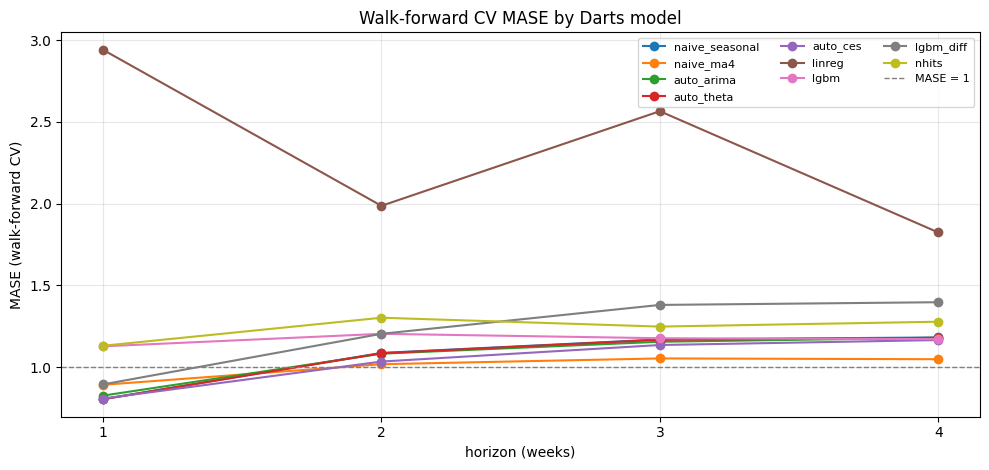

In [8]:
# CV MASE by horizon
fig, ax = plt.subplots(figsize=(10, 4.8))
for name in MODEL_ORDER:
    sub = cv_table[cv_table["model"] == name]
    ax.plot(sub["horizon"], sub["MASE"], marker="o", label=name)
ax.axhline(1.0, color="grey", lw=1, ls="--", label="MASE = 1")
ax.set_xticks(HORIZONS)
ax.set_xlabel("horizon (weeks)")
ax.set_ylabel("MASE (walk-forward CV)")
ax.set_title("Walk-forward CV MASE by Darts model")
ax.legend(ncols=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "cv_mase_by_horizon.png", dpi=130)
plt.show()


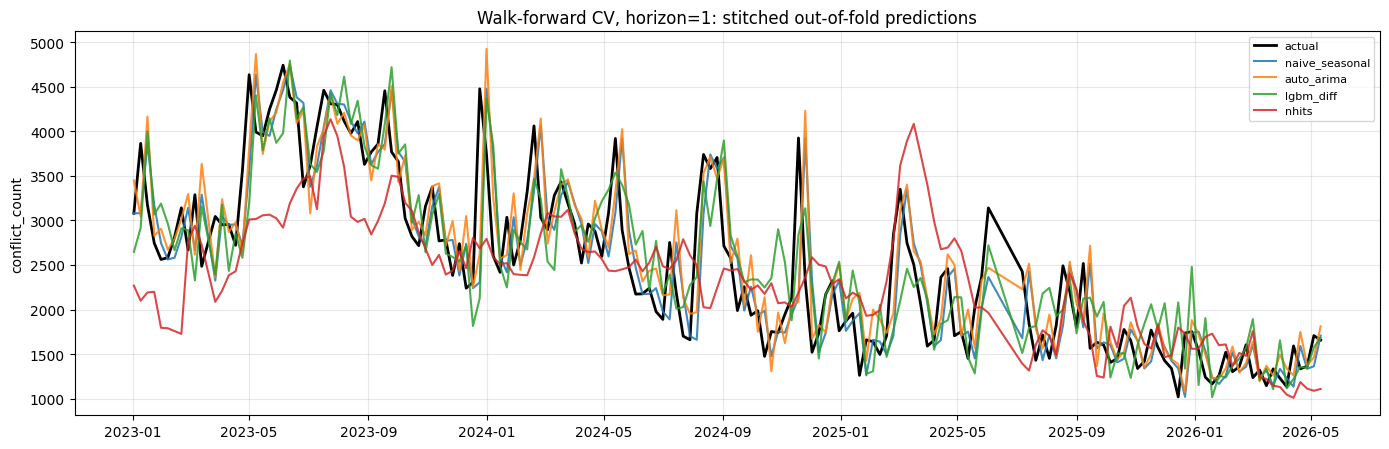

In [9]:
# Stitched out-of-fold predictions at h=1
h1 = cv_df[cv_df["horizon"] == 1]
fig, ax = plt.subplots(figsize=(14, 4.6))
actual = h1[h1["model"] == MODEL_ORDER[0]].sort_values("week")
ax.plot(actual["week"], actual["y_true"], color="black", lw=2, label="actual")
highlight = ["naive_seasonal", "auto_arima", "lgbm_diff", "nhits"]
for name in highlight:
    sub = h1[h1["model"] == name].sort_values("week")
    ax.plot(sub["week"], sub["y_pred"], alpha=0.85, label=name)
ax.set_title("Walk-forward CV, horizon=1: stitched out-of-fold predictions")
ax.set_ylabel("conflict_count")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "cv_stitched_h1.png", dpi=130)
plt.show()


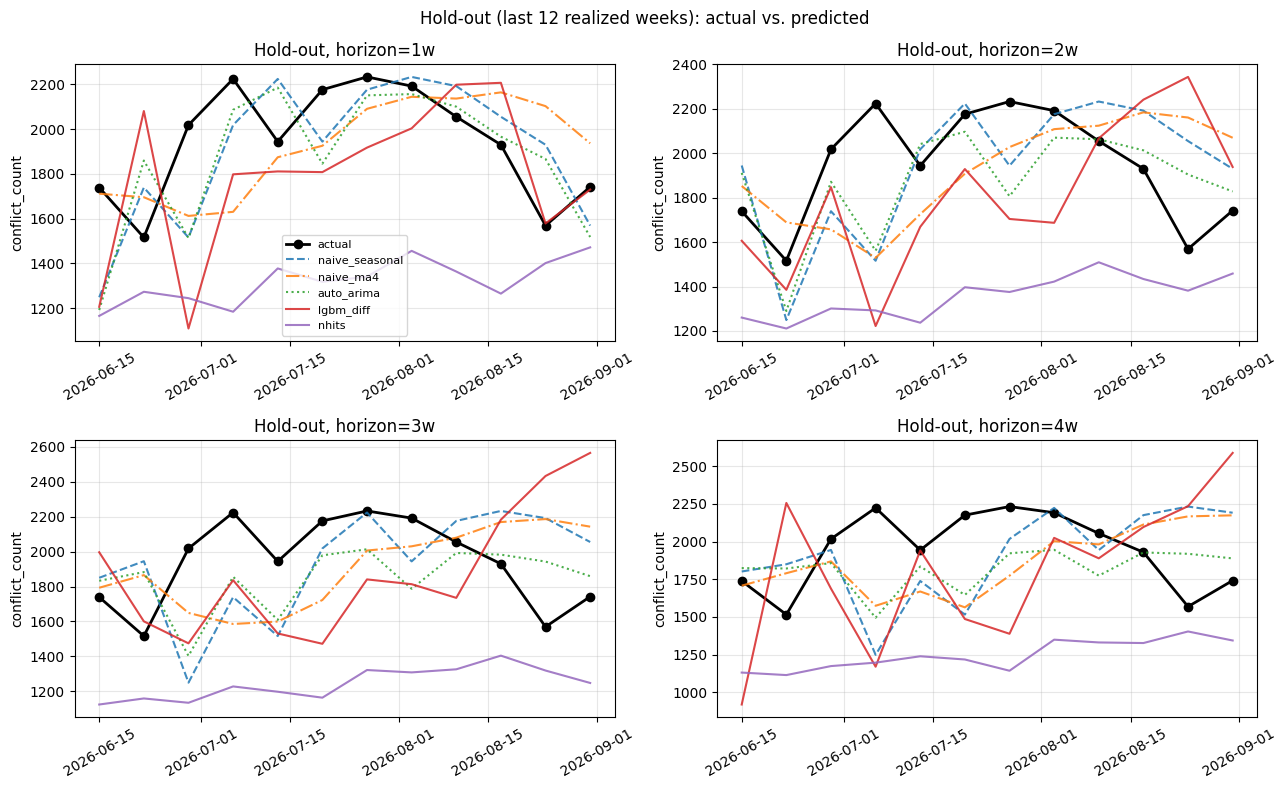

In [10]:
# Hold-out actual vs predicted, all horizons
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
plot_models = [
    ("naive_seasonal", "--"),
    ("naive_ma4", "-."),
    ("auto_arima", ":"),
    ("lgbm_diff", "-"),
    ("nhits", "-"),
]
for ax, h in zip(axes.flat, HORIZONS):
    sub = ho_df[ho_df["horizon"] == h]
    actual = sub[sub["model"] == "naive_seasonal"].sort_values("week")
    ax.plot(actual["week"], actual["y_true"], "o-", color="black", lw=2, label="actual")
    for name, style in plot_models:
        m = sub[sub["model"] == name].sort_values("week")
        ax.plot(m["week"], m["y_pred"], style, label=name, alpha=0.85)
    ax.set_title(f"Hold-out, horizon={h}w")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("conflict_count")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Hold-out (last 12 realized weeks): actual vs. predicted")
fig.tight_layout()
fig.savefig(FIG_DIR / "holdout_actual_vs_predicted.png", dpi=130)
plt.show()


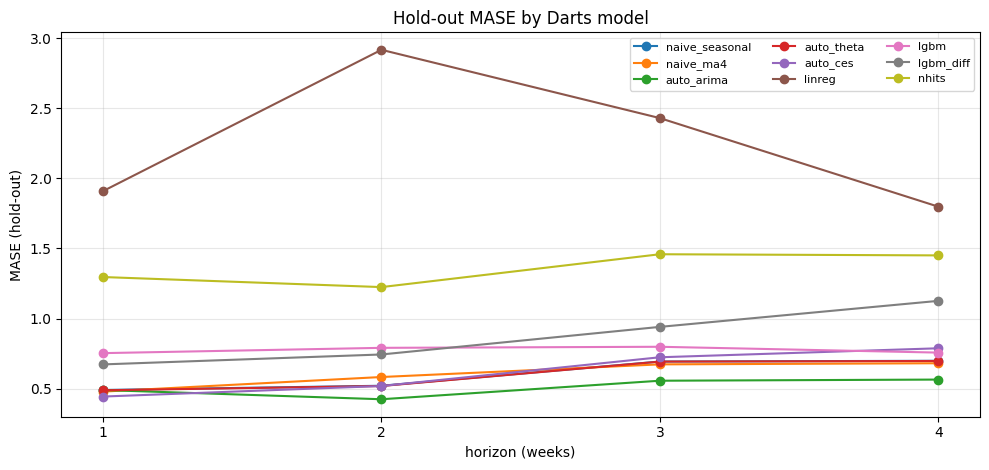

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for name in MODEL_ORDER:
    sub = ho_table[ho_table["model"] == name]
    ax.plot(sub["horizon"], sub["MASE"], marker="o", label=name)
ax.set_xticks(HORIZONS)
ax.set_xlabel("horizon (weeks)")
ax.set_ylabel("MASE (hold-out)")
ax.set_title("Hold-out MASE by Darts model")
ax.legend(ncols=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "holdout_mase_by_horizon.png", dpi=130)
plt.show()


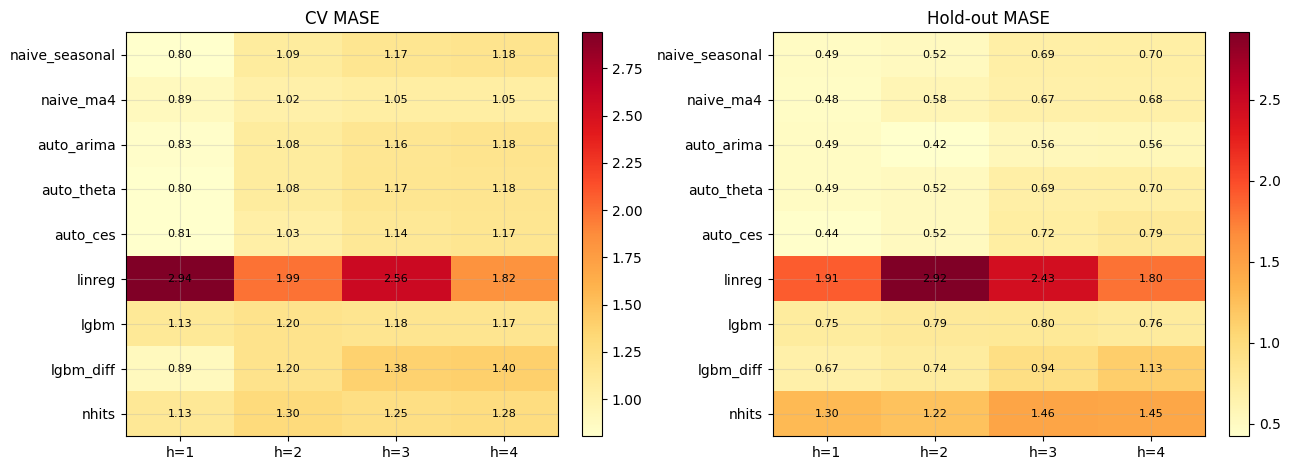

,CV h=1,CV h=2,CV h=3,CV h=4,HO h=1,HO h=2,HO h=3,HO h=4
model,,,,,,,,
naive_seasonal,0.804,1.087,1.169,1.181,0.490,0.520,0.693,0.698
naive_ma4,0.892,1.018,1.053,1.048,0.479,0.583,0.673,0.681
auto_arima,0.826,1.082,1.155,1.179,0.490,0.424,0.556,0.564
auto_theta,0.803,1.085,1.167,1.179,0.488,0.519,0.693,0.697
auto_ces,0.808,1.034,1.135,1.165,0.443,0.519,0.724,0.788
linreg,2.940,1.986,2.565,1.824,1.909,2.917,2.430,1.798
lgbm,1.127,1.204,1.177,1.171,0.753,0.791,0.798,0.757
lgbm_diff,0.894,1.204,1.380,1.397,0.673,0.743,0.940,1.126
nhits,1.131,1.302,1.248,1.278,1.296,1.224,1.458,1.450


In [12]:
# Side-by-side CV vs hold-out MASE heatmap-style table
cv_m = cv_table.pivot(index="model", columns="horizon", values="MASE").reindex(MODEL_ORDER)
ho_m = ho_table.pivot(index="model", columns="horizon", values="MASE").reindex(MODEL_ORDER)
cv_m.columns = [f"CV h={c}" for c in cv_m.columns]
ho_m.columns = [f"HO h={c}" for c in ho_m.columns]
combined = pd.concat([cv_m, ho_m], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, mat, title in (
    (axes[0], cv_table.pivot(index="model", columns="horizon", values="MASE").reindex(MODEL_ORDER), "CV MASE"),
    (axes[1], ho_table.pivot(index="model", columns="horizon", values="MASE").reindex(MODEL_ORDER), "Hold-out MASE"),
):
    im = ax.imshow(mat.to_numpy(), aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(HORIZONS)), [f"h={h}" for h in HORIZONS])
    ax.set_yticks(range(len(MODEL_ORDER)), MODEL_ORDER)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.to_numpy()[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIG_DIR / "mase_heatmaps.png", dpi=130)
plt.show()
combined.round(3)


## 7. Future 1–4 week forecast

Fit every model on the **full** observed series (last origin = most recent
complete week) and forecast `h = 1..4`.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=30` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Wrote /home/romanrussia/Code_git/GDETL/outputs/darts/forecast.csv


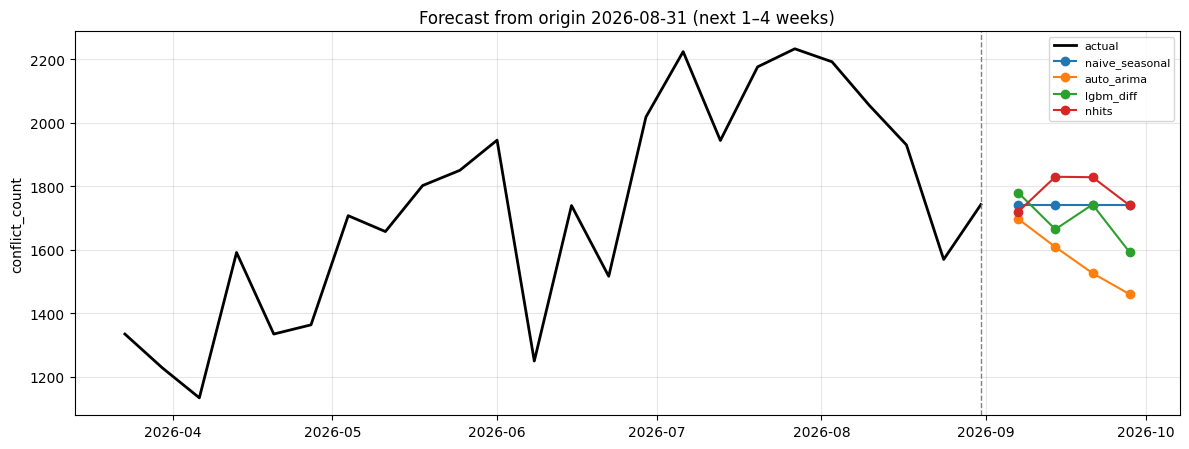

,country,origin_week,target_week,horizon_weeks,naive_seasonal,naive_ma4,auto_arima,auto_theta,auto_ces,linreg,lgbm,lgbm_diff,nhits
0,Ukraine,2026-08-31,2026-09-07,1,1742.0,1824.0,1696.9,1740.3,1686.4,1691.4,1881.9,1779.8,1719.1
1,Ukraine,2026-08-31,2026-09-14,2,1742.0,1766.2,1608.3,1740.3,1621.1,1917.8,1893.6,1664.0,1829.7
2,Ukraine,2026-08-31,2026-09-21,3,1742.0,1725.3,1525.7,1740.3,1595.6,1844.0,1896.5,1742.1,1828.2
3,Ukraine,2026-08-31,2026-09-28,4,1742.0,1764.4,1459.3,1740.3,1541.3,1781.3,2104.0,1591.2,1739.2


In [13]:
models_full = make_models(SEED)
last_idx = len(series) - 1
fit_models_on_prefix(models_full, last_idx)
future_preds = predict_origin(models_full, last_idx)
last_week = times[last_idx]
forecast_weeks = [last_week + pd.Timedelta(weeks=h) for h in HORIZONS]

forecast_rows = []
for h in HORIZONS:
    row = {
        "country": cfg["country"]["name"],
        "origin_week": str(last_week.date()),
        "target_week": str(forecast_weeks[h - 1].date()),
        "horizon_weeks": h,
    }
    for name in MODEL_ORDER:
        row[name] = round(float(future_preds[name][h - 1]), 1)
    forecast_rows.append(row)

forecast_df = pd.DataFrame(forecast_rows)
forecast_path = OUT_DIR / "forecast.csv"
forecast_df.to_csv(forecast_path, index=False)
print(f"Wrote {forecast_path}")

fig, ax = plt.subplots(figsize=(12, 4.6))
hist = raw.tail(24)
ax.plot(hist["week_start"], hist["conflict_count"], color="black", lw=2, label="actual")
for name in ["naive_seasonal", "auto_arima", "lgbm_diff", "nhits"]:
    ax.plot(forecast_weeks, [future_preds[name][h - 1] for h in HORIZONS], marker="o", label=name)
ax.axvline(last_week, color="grey", ls="--", lw=1)
ax.set_title(f"Forecast from origin {last_week.date()} (next 1–4 weeks)")
ax.set_ylabel("conflict_count")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "future_forecast.png", dpi=130)
plt.show()
forecast_df


In [14]:
metrics_out = {
    "cv": {
        str(h): {
            row["model"]: {k: float(row[k]) if k != "model" else row[k]
                           for k in ["MASE", "sMAPE", "RMSE", "MAE", "n", "vs_naive_pct"]}
            for row in cv_table[cv_table["horizon"] == h].to_dict(orient="records")
        }
        for h in HORIZONS
    },
    "holdout": {
        str(h): {
            row["model"]: {k: float(row[k]) if k != "model" else row[k]
                           for k in ["MASE", "sMAPE", "RMSE", "MAE", "n", "vs_naive_pct"]}
            for row in ho_table[ho_table["horizon"] == h].to_dict(orient="records")
        }
        for h in HORIZONS
    },
    "n_cv_folds": n_folds,
    "holdout_start": str(holdout_start),
    "models": MODEL_ORDER,
}
write_json(OUT_DIR / "metrics.json", metrics_out)

best_cv = cv_table.loc[cv_table.groupby("horizon")["MASE"].idxmin(), ["horizon", "model", "MASE", "vs_naive_pct"]]
best_ho = ho_table.loc[ho_table.groupby("horizon")["MASE"].idxmin(), ["horizon", "model", "MASE", "vs_naive_pct"]]
print("Best CV model per horizon:")
display(best_cv.round(3))
print("Best hold-out model per horizon:")
display(best_ho.round(3))
print(f"Wrote {OUT_DIR / 'metrics.json'}")
print(f"Figures in {FIG_DIR}")


Best CV model per horizon:


,horizon,model,MASE,vs_naive_pct
0,1,auto_theta,0.803,0.092
9,2,naive_ma4,1.018,6.340
18,3,naive_ma4,1.053,9.928
27,4,naive_ma4,1.048,11.258


Best hold-out model per horizon:


,horizon,model,MASE,vs_naive_pct
0,1,auto_ces,0.443,9.567
9,2,auto_arima,0.424,18.510
18,3,auto_arima,0.556,19.742
27,4,auto_arima,0.564,19.190


Wrote /home/romanrussia/Code_git/GDETL/outputs/darts/metrics.json
Figures in /home/romanrussia/Code_git/GDETL/outputs/darts/figures


## 8. Takeaways (wave 1)

Walk-forward CV (`n=171` / horizon, 44 folds) and the last-12-week hold-out
agree on the same story as the original pipeline, with one important upgrade:

- **CV (most reliable):** `naive_ma4` is best at h=2/3/4 (MASE 1.02–1.05, **+6% to +11% vs naive**).
  At h=1, `auto_theta` ties persistence (MASE 0.803 vs 0.804). Non-seasonal
  AutoARIMA/AutoCES are within a few percent of naive — unlike the original
  Holt-Winters ETS, which was ~2× worse.
- **Hold-out (n=12, noisier):** `auto_ces` wins h=1 (**+9.6%** vs naive);
  `auto_arima` wins h=2/3/4 (**+18–20%**). Treat this as a small-sample hint,
  not a replacement for the 44-fold CV ranking.
- **Trees and N-HiTS lose.** Level LightGBM, `lgbm_diff`, and N-HiTS are
  10–40% worse than naive on CV and worse still on hold-out. Linear regression
  on raw lags is the worst model (collinear unscaled features + a near-unit-root
  level). A GBDT on this series still has to beat "next week ≈ this week".
- `season_length=1` is the difference vs ETS: these statistical models are not
  forced into a 52-week seasonal pattern that the war-driven series does not have.
- Incomplete GDELT weeks are masked as targets, matching `src/pipeline.py`.
  Artifacts: `outputs/darts/metrics.json`, `outputs/darts/forecast.csv`,
  `outputs/darts/figures/`.

Wave 2 (Ridge, Kalman, DLinear, TFT, …) is in sections 9–13; the combined
ranking is section 12.


## 9. Extended interpretable models (full CV)

Same 44-fold expanding window and 12-week hold-out as wave 1. New models are
chosen to stay **readable**:

- **Damped Holt** (`ExponentialSmoothing`, no yearly seasonality) — the original
  pipeline ETS failed because it was forced into a 52-week season; this is the
  level+trend member of that family.
- **Kalman** — 2-dimensional state (level, trend) with calendar future covariates
  as the control signal.
- **Ridge** — the wave-1 `linreg` blew up on unscaled, collinear lags. Ridge
  after `StandardScaler` keeps a linear, coefficient-level explanation.
- **XGBoost / shallow Random Forest** — same lag/covariate recipe as LightGBM,
  but we keep them for gain / impurity importance in section 11.

DLinear / NLinear are linear neural nets, so they also run on the full CV
(section 10 starts with their factory; they are scored here together with the
tabular/stat models so the MASE table stays in one place).


In [15]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from darts.models import (
    DLinearModel,
    ExponentialSmoothing,
    KalmanForecaster,
    NBEATSModel,
    NLinearModel,
    RandomForestModel,
    SKLearnModel,
    TFTModel,
    TransformerModel,
    XGBModel,
)
from darts.dataprocessing.transformers import Scaler
from darts.utils.utils import ModelMode, SeasonalityMode
from darts.explainability import TFTExplainer

PL_KW = {
    "enable_progress_bar": False,
    "accelerator": "cpu",
    "enable_model_summary": False,
}
TORCH_DIR = OUT_DIR / "torch_work"
TORCH_DIR.mkdir(parents=True, exist_ok=True)

FAST_LOCAL = {"ets_holt"}
FAST_TRANSFER = {"kalman"}
FAST_GLOBAL = {"ridge", "xgb", "rf"}
LINEAR_NN = {"dlinear", "nlinear"}
ATTN_PAST = {"nbeats_i", "transformer"}
ATTN_MIXED = {"tft"}

FAST_ORDER = ["ets_holt", "kalman", "ridge", "xgb", "rf", "dlinear", "nlinear"]
ATTN_ORDER = ["nbeats_i", "tft", "transformer"]


def _torch_common(seed: int, name: str) -> dict:
    return dict(
        n_epochs=40,
        batch_size=16,
        random_state=seed,
        optimizer_kwargs={"lr": 1e-3},
        pl_trainer_kwargs=PL_KW,
        save_checkpoints=False,
        force_reset=True,
        show_warnings=False,
        model_name=name,
        work_dir=str(TORCH_DIR),
    )


def make_fast_models(seed: int = 42) -> dict:
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0)),
    ])
    tab_kw = dict(
        lags=LAGS,
        lags_past_covariates=LAGS_PAST,
        lags_future_covariates=LAGS_FUTURE,
        output_chunk_length=MAX_H,
        multi_models=True,
        random_state=seed,
    )
    return {
        "ets_holt": ExponentialSmoothing(
            trend=ModelMode.ADDITIVE,
            damped=True,
            seasonal=SeasonalityMode.NONE,
        ),
        "kalman": KalmanForecaster(dim_x=2, random_state=seed),
        "ridge": SKLearnModel(model=ridge, **tab_kw),
        "xgb": XGBModel(
            **tab_kw,
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=8,
            verbosity=0,
        ),
        "rf": RandomForestModel(
            **tab_kw,
            n_estimators=200,
            max_depth=4,
            min_samples_leaf=8,
        ),
        "dlinear": DLinearModel(
            input_chunk_length=16,
            output_chunk_length=MAX_H,
            kernel_size=7,
            shared_weights=False,
            const_init=True,
            **_torch_common(seed, "dlinear"),
        ),
        "nlinear": NLinearModel(
            input_chunk_length=16,
            output_chunk_length=MAX_H,
            shared_weights=False,
            const_init=True,
            normalize=True,
            **_torch_common(seed, "nlinear"),
        ),
    }


def make_attn_models(seed: int = 42) -> dict:
    return {
        "nbeats_i": NBEATSModel(
            input_chunk_length=16,
            output_chunk_length=MAX_H,
            generic_architecture=False,  # trend + seasonality stacks
            num_blocks=1,
            num_layers=2,
            layer_widths=64,
            expansion_coefficient_dim=5,
            trend_polynomial_degree=2,
            dropout=0.1,
            **_torch_common(seed, "nbeats_i"),
        ),
        "tft": TFTModel(
            input_chunk_length=16,
            output_chunk_length=MAX_H,
            hidden_size=16,
            lstm_layers=1,
            num_attention_heads=2,
            dropout=0.2,
            hidden_continuous_size=8,
            add_relative_index=True,
            **_torch_common(seed, "tft"),
        ),
        "transformer": TransformerModel(
            input_chunk_length=16,
            output_chunk_length=MAX_H,
            d_model=32,
            nhead=4,
            num_encoder_layers=1,
            num_decoder_layers=1,
            dim_feedforward=64,
            dropout=0.2,
            **_torch_common(seed, "transformer"),
        ),
    }


def fit_fast_on_prefix(models: dict, train_end_inclusive: int) -> dict:
    """Fit wave-2 models that share the original series scale (no extra Scaler)."""
    train_s = _slice_end(series, train_end_inclusive)
    train_past = _slice_end(past_cov, train_end_inclusive)
    for name, model in models.items():
        if name in FAST_LOCAL:
            continue
        if name in FAST_TRANSFER:
            try:
                model.fit(train_s, future_covariates=future_cov)
            except Exception as exc:
                print(f"  warn: {name} fit with future cov failed ({exc}); univariate Kalman")
                model.fit(train_s)
        elif name in LINEAR_NN:
            model.fit(train_s, past_covariates=train_past, future_covariates=future_cov, verbose=False)
        else:
            model.fit(train_s, past_covariates=train_past, future_covariates=future_cov)
    return models


def predict_fast_origin(models: dict, origin_idx: int) -> dict[str, np.ndarray]:
    hist = _slice_end(series, origin_idx)
    last_level = float(series.values()[origin_idx, 0])
    out = {}
    for name, model in models.items():
        try:
            if name in FAST_LOCAL:
                model.fit(hist)
                pred = model.predict(MAX_H)
            elif name in FAST_TRANSFER:
                try:
                    pred = model.predict(MAX_H, series=hist, future_covariates=future_cov)
                except TypeError:
                    pred = model.predict(MAX_H, series=hist)
            elif name in LINEAR_NN:
                pred = model.predict(
                    MAX_H, series=hist, past_covariates=past_cov, future_covariates=future_cov
                )
            else:
                pred = model.predict(
                    MAX_H, series=hist, past_covariates=past_cov, future_covariates=future_cov
                )
            out[name] = np.maximum(pred.values().ravel()[:MAX_H], 0.0)
        except Exception as exc:
            print(f"  warn: {name} origin={origin_idx} failed ({exc}); last-level fallback")
            out[name] = np.full(MAX_H, max(last_level, 0.0))
    return out


print("fast/linear-nn models:", FAST_ORDER)
print("attention/transformer models:", ATTN_ORDER)


fast/linear-nn models: ['ets_holt', 'kalman', 'ridge', 'xgb', 'rf', 'dlinear', 'nlinear']
attention/transformer models: ['nbeats_i', 'tft', 'transformer']


In [16]:
# --- Wave 2 full-CV (stat / ridge / trees / DLinear / NLinear) ---
fast_cv_records = []
n_folds = len(folds)
train_history_cv = cv_pool["conflict_count"].to_numpy(dtype=float)

for fold_i, (train_range, test_range) in enumerate(folds):
    train_end = train_range.stop - 1
    models_f = make_fast_models(SEED)
    fit_fast_on_prefix(models_f, train_end)
    test_origins = list(test_range)
    for origin_idx in test_origins:
        preds = predict_fast_origin(models_f, origin_idx)
        origin_time = times[origin_idx]
        for h in HORIZONS:
            target_idx = origin_idx + h
            if target_idx >= len(series):
                continue
            target_time = times[target_idx]
            if pd.Timestamp(target_time).normalize() in incomplete_weeks:
                continue
            y_true = float(series.values()[target_idx, 0])
            for name in FAST_ORDER:
                fast_cv_records.append({
                    "fold": fold_i,
                    "horizon": h,
                    "model": name,
                    "origin": origin_time,
                    "week": target_time,
                    "y_true": y_true,
                    "y_pred": float(preds[name][h - 1]),
                })
    print(
        f"fast CV fold {fold_i + 1}/{n_folds}: train={train_end + 1} weeks, "
        f"test origins={len(test_origins)} ({times[test_origins[0]].date()} .. {times[test_origins[-1]].date()})"
    )

fast_cv_df = pd.DataFrame(fast_cv_records)
fast_cv_table = add_vs_baseline(score_records(fast_cv_records, train_history_cv))
print("\nWave-2 walk-forward CV MASE")
fast_cv_table[display_cols].round(3)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=40` reached.


GPU available: False, used: False


...

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


fast CV fold 44/44: train=224 weeks, test origins=4 (2026-04-13 .. 2026-05-04)

Wave-2 walk-forward CV MASE


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,ets_holt,0.804,15.854,518.707,386.495,171,NaN
1,1,nlinear,0.856,16.667,547.281,411.437,171,NaN
2,1,dlinear,1.065,20.339,644.786,511.714,171,NaN
3,1,xgb,1.109,20.792,712.482,533.023,171,NaN
4,1,rf,1.111,20.707,647.211,533.763,171,NaN
5,1,ridge,1.111,24.239,697.253,533.873,171,NaN
6,1,kalman,1.261,24.525,937.803,606.257,171,NaN
7,2,nlinear,1.073,21.379,672.837,515.702,171,NaN
8,2,ets_holt,1.087,21.774,708.175,522.265,171,NaN
9,2,rf,1.129,21.040,658.609,542.816,171,NaN


In [17]:
# Hold-out for wave-2 full-CV models (fit on CV pool only)
fast_ho_records = []
models_fast_ho = make_fast_models(SEED)
fit_fast_on_prefix(models_fast_ho, n_cv - 1)
train_history_ho = cv_pool["conflict_count"].to_numpy(dtype=float)

origin_needed = set()
for h in HORIZONS:
    for w in holdout_times:
        origin_needed.add(w - pd.Timedelta(weeks=h))
origin_needed = sorted(t for t in origin_needed if t in times)
time_to_idx = {t: i for i, t in enumerate(times)}

fast_pred_cache = {}
for origin_time in origin_needed:
    origin_idx = time_to_idx[origin_time]
    fast_pred_cache[origin_idx] = predict_fast_origin(models_fast_ho, origin_idx)

for h in HORIZONS:
    for target_time in holdout_times:
        if pd.Timestamp(target_time).normalize() in incomplete_weeks:
            continue
        origin_time = target_time - pd.Timedelta(weeks=h)
        if origin_time not in time_to_idx:
            continue
        origin_idx = time_to_idx[origin_time]
        target_idx = time_to_idx[target_time]
        y_true = float(series.values()[target_idx, 0])
        preds = fast_pred_cache[origin_idx]
        for name in FAST_ORDER:
            fast_ho_records.append({
                "horizon": h,
                "model": name,
                "origin": origin_time,
                "week": target_time,
                "y_true": y_true,
                "y_pred": float(preds[name][h - 1]),
            })

fast_ho_df = pd.DataFrame(fast_ho_records)
fast_ho_table = add_vs_baseline(score_records(fast_ho_records, train_history_ho))
print("Wave-2 hold-out MASE (positive vs_naive_pct = better than naive)")
fast_ho_table[display_cols].round(3)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=40` reached.


GPU available: False, used: False


...

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Wave-2 hold-out MASE (positive vs_naive_pct = better than naive)


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,kalman,0.436,11.322,246.737,209.598,12,NaN
1,1,ets_holt,0.490,13.131,276.295,235.583,12,NaN
2,1,nlinear,0.579,15.254,337.318,278.490,12,NaN
3,1,rf,0.775,20.445,429.597,372.418,12,NaN
4,1,xgb,0.795,21.377,435.473,382.027,12,NaN
5,1,dlinear,1.212,34.644,634.819,582.307,12,NaN
6,1,ridge,1.484,45.267,752.301,713.138,12,NaN
7,2,kalman,0.479,12.012,290.938,230.079,12,NaN
8,2,ets_holt,0.520,13.481,310.410,250.083,12,NaN
9,2,nlinear,0.789,20.928,444.986,379.156,12,NaN


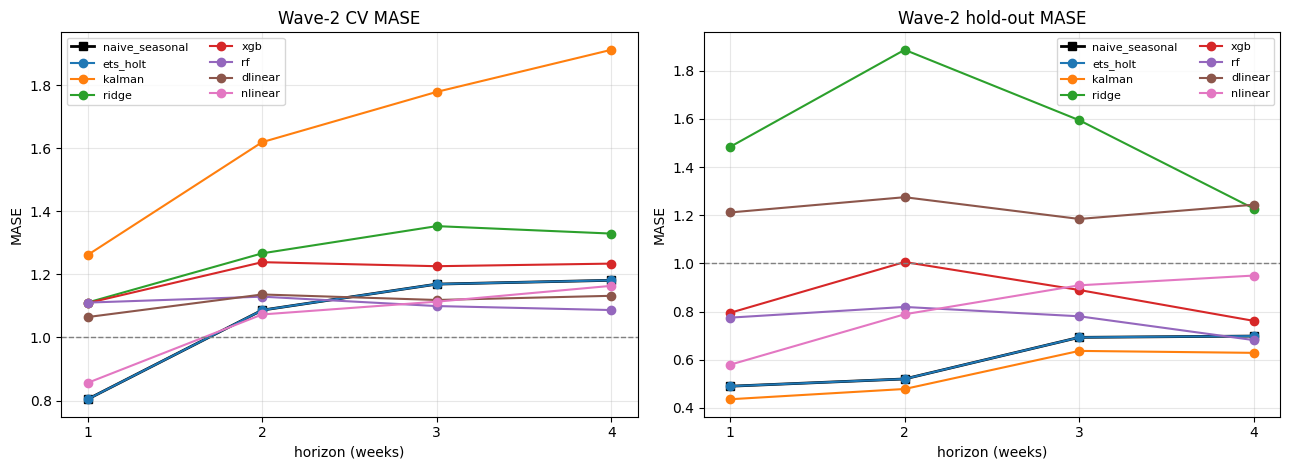

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, table, orig, title in (
    (axes[0], fast_cv_table, cv_table, "Wave-2 CV MASE"),
    (axes[1], fast_ho_table, ho_table, "Wave-2 hold-out MASE"),
):
    naive = orig[orig["model"] == "naive_seasonal"]
    ax.plot(naive["horizon"], naive["MASE"], marker="s", color="black", lw=2, label="naive_seasonal")
    for name in FAST_ORDER:
        sub = table[table["model"] == name]
        if sub.empty:
            continue
        ax.plot(sub["horizon"], sub["MASE"], marker="o", label=name)
    ax.axhline(1.0, color="grey", lw=1, ls="--")
    ax.set_xticks(HORIZONS)
    ax.set_xlabel("horizon (weeks)")
    ax.set_ylabel("MASE")
    ax.set_title(title)
    ax.legend(ncols=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "wave2_mase_by_horizon.png", dpi=130)
plt.show()


## 10. Neural / transformer models

Three heavier architectures, kept **small** (one attention block / tiny TFT,
40 epochs, CPU):

| Model | Interpretable piece | Covariates |
|---|---|---|
| `NBEATSModel(generic_architecture=False)` | Polynomial trend stack + Fourier-like seasonality stack | none (keeps stacks readable) |
| `TFTModel` | Variable-selection network + temporal attention | past + future |
| `TransformerModel` | Encoder–decoder attention (black box; foil) | past |

Protocol: expanding-window CV on the **last 12 folds only** (recent regime,
enough history for `input_chunk_length=16`) and the same 12-week hold-out as
everyone else. Target and covariates are **min–max scaled on the training
prefix** then inverted — neural nets on raw counts of 1k–3k events otherwise
just learn the level.


In [19]:
def fit_attn_on_prefix(models: dict, train_end_inclusive: int) -> dict:
    """Fit TFT / Transformer / interpretable N-BEATS with train-only scalers."""
    sy, sp, sf = Scaler(), Scaler(), Scaler()
    y_tr = sy.fit_transform(_slice_end(series, train_end_inclusive))
    p_tr = sp.fit_transform(_slice_end(past_cov, train_end_inclusive))
    f_all = sf.fit_transform(future_cov)
    bundled = {"y": sy, "p": sp, "f": sf}
    for name, model in models.items():
        if name in ATTN_PAST and name == "nbeats_i":
            model.fit(y_tr, verbose=False)
        elif name in ATTN_PAST:
            model.fit(y_tr, past_covariates=p_tr, verbose=False)
        else:
            model.fit(
                y_tr,
                past_covariates=p_tr,
                future_covariates=f_all,
                verbose=False,
            )
    return bundled


def predict_attn_origin(models: dict, scalers: dict, origin_idx: int) -> dict[str, np.ndarray]:
    last_level = float(series.values()[origin_idx, 0])
    hist_s = scalers["y"].transform(_slice_end(series, origin_idx))
    past_s = scalers["p"].transform(past_cov)
    fut_s = scalers["f"].transform(future_cov)
    out = {}
    for name, model in models.items():
        try:
            if name == "nbeats_i":
                pred_s = model.predict(MAX_H, series=hist_s)
            elif name in ATTN_PAST:
                pred_s = model.predict(MAX_H, series=hist_s, past_covariates=past_s)
            else:
                pred_s = model.predict(
                    MAX_H, series=hist_s, past_covariates=past_s, future_covariates=fut_s
                )
            pred = scalers["y"].inverse_transform(pred_s)
            out[name] = np.maximum(pred.values().ravel()[:MAX_H], 0.0)
        except Exception as exc:
            print(f"  warn: {name} origin={origin_idx} failed ({exc}); last-level fallback")
            out[name] = np.full(MAX_H, max(last_level, 0.0))
    return out


RECENT_FOLDS = folds[-12:]
print(f"attention CV: last {len(RECENT_FOLDS)} of {len(folds)} folds")


attention CV: last 12 of 44 folds


In [20]:
attn_cv_records = []
for fold_i, (train_range, test_range) in enumerate(RECENT_FOLDS):
    global_fold = len(folds) - len(RECENT_FOLDS) + fold_i
    train_end = train_range.stop - 1
    models_a = make_attn_models(SEED)
    scalers_a = fit_attn_on_prefix(models_a, train_end)
    test_origins = list(test_range)
    for origin_idx in test_origins:
        preds = predict_attn_origin(models_a, scalers_a, origin_idx)
        origin_time = times[origin_idx]
        for h in HORIZONS:
            target_idx = origin_idx + h
            if target_idx >= len(series):
                continue
            target_time = times[target_idx]
            if pd.Timestamp(target_time).normalize() in incomplete_weeks:
                continue
            y_true = float(series.values()[target_idx, 0])
            for name in ATTN_ORDER:
                attn_cv_records.append({
                    "fold": global_fold,
                    "horizon": h,
                    "model": name,
                    "origin": origin_time,
                    "week": target_time,
                    "y_true": y_true,
                    "y_pred": float(preds[name][h - 1]),
                })
    print(
        f"attn CV fold {fold_i + 1}/{len(RECENT_FOLDS)} (global {global_fold + 1}/{len(folds)}): "
        f"train={train_end + 1} weeks, origins={len(test_origins)}"
    )

attn_cv_df = pd.DataFrame(attn_cv_records)
attn_cv_table = add_vs_baseline(score_records(attn_cv_records, train_history_cv))
print("\nAttention-class models, last-12-fold CV MASE (not comparable n vs wave 1)")
attn_cv_table[display_cols].round(3)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=40` reached.


GPU available: False, used: False


...

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


attn CV fold 12/12 (global 44/44): train=224 weeks, origins=4

Attention-class models, last-12-fold CV MASE (not comparable n vs wave 1)


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,transformer,0.533,15.816,336.720,256.339,45,NaN
1,1,nbeats_i,0.637,18.647,391.077,306.196,45,NaN
2,1,tft,3.613,59.574,2411.493,1736.280,45,NaN
3,2,nbeats_i,0.615,18.050,383.816,295.663,46,NaN
4,2,transformer,0.800,22.515,499.508,384.494,46,NaN
5,2,tft,1.321,36.007,726.717,634.853,46,NaN
6,3,nbeats_i,0.642,19.428,385.004,308.730,47,NaN
7,3,transformer,0.847,23.922,478.897,407.015,47,NaN
8,3,tft,1.153,29.456,745.243,554.173,47,NaN
9,4,nbeats_i,0.650,19.382,397.453,312.252,48,NaN


In [21]:
# Same recent-fold window scored for naive, so the attention table has a baseline
naive_recent_records = []
for fold_i, (train_range, test_range) in enumerate(RECENT_FOLDS):
    global_fold = len(folds) - len(RECENT_FOLDS) + fold_i
    naive = NaiveSeasonal(K=1)
    for origin_idx in test_range:
        hist = _slice_end(series, origin_idx)
        naive.fit(hist)
        pred = np.maximum(naive.predict(MAX_H).values().ravel()[:MAX_H], 0.0)
        origin_time = times[origin_idx]
        for h in HORIZONS:
            target_idx = origin_idx + h
            if target_idx >= len(series):
                continue
            target_time = times[target_idx]
            if pd.Timestamp(target_time).normalize() in incomplete_weeks:
                continue
            naive_recent_records.append({
                "fold": global_fold,
                "horizon": h,
                "model": "naive_seasonal",
                "origin": origin_time,
                "week": target_time,
                "y_true": float(series.values()[target_idx, 0]),
                "y_pred": float(pred[h - 1]),
            })

attn_cv_with_naive = add_vs_baseline(
    score_records(attn_cv_records + naive_recent_records, train_history_cv)
)
print("Last-12-fold CV: attention models vs persistence")
attn_cv_with_naive[display_cols].round(3)


Last-12-fold CV: attention models vs persistence


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,transformer,0.533,15.816,336.720,256.339,45,6.453
1,1,naive_seasonal,0.570,16.823,350.147,274.022,45,0.000
2,1,nbeats_i,0.637,18.647,391.077,306.196,45,-11.741
3,1,tft,3.613,59.574,2411.493,1736.280,45,-533.627
4,2,nbeats_i,0.615,18.050,383.816,295.663,46,15.330
5,2,naive_seasonal,0.727,22.774,522.321,349.196,46,0.000
6,2,transformer,0.800,22.515,499.508,384.494,46,-10.108
7,2,tft,1.321,36.007,726.717,634.853,46,-81.804
8,3,nbeats_i,0.642,19.428,385.004,308.730,47,16.846
9,3,naive_seasonal,0.773,26.086,571.567,371.277,47,0.000


In [22]:
attn_ho_records = []
models_attn_ho = make_attn_models(SEED)
scalers_attn_ho = fit_attn_on_prefix(models_attn_ho, n_cv - 1)

attn_pred_cache = {}
for origin_time in origin_needed:
    origin_idx = time_to_idx[origin_time]
    attn_pred_cache[origin_idx] = predict_attn_origin(models_attn_ho, scalers_attn_ho, origin_idx)

for h in HORIZONS:
    for target_time in holdout_times:
        if pd.Timestamp(target_time).normalize() in incomplete_weeks:
            continue
        origin_time = target_time - pd.Timedelta(weeks=h)
        if origin_time not in time_to_idx:
            continue
        origin_idx = time_to_idx[origin_time]
        target_idx = time_to_idx[target_time]
        y_true = float(series.values()[target_idx, 0])
        preds = attn_pred_cache[origin_idx]
        for name in ATTN_ORDER:
            attn_ho_records.append({
                "horizon": h,
                "model": name,
                "origin": origin_time,
                "week": target_time,
                "y_true": y_true,
                "y_pred": float(preds[name][h - 1]),
            })

attn_ho_df = pd.DataFrame(attn_ho_records)
attn_ho_table = add_vs_baseline(score_records(attn_ho_records, train_history_ho))
print("Attention-class hold-out MASE")
attn_ho_table[display_cols].round(3)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=40` reached.


GPU available: False, used: False


...

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Attention-class hold-out MASE


,horizon,model,MASE,sMAPE,RMSE,MAE,n,vs_naive_pct
0,1,nbeats_i,0.697,18.359,396.867,335.087,12,NaN
1,1,transformer,1.444,42.488,736.693,693.865,12,NaN
2,1,tft,2.891,68.029,1888.324,1389.631,12,NaN
3,2,nbeats_i,0.992,27.375,544.739,476.902,12,NaN
4,2,tft,1.201,36.992,704.979,577.135,12,NaN
5,2,transformer,1.242,35.365,648.384,597.074,12,NaN
6,3,transformer,0.885,23.708,481.224,425.378,12,NaN
7,3,nbeats_i,1.196,34.045,646.547,574.689,12,NaN
8,3,tft,1.476,45.553,806.057,709.570,12,NaN
9,4,nbeats_i,0.915,24.735,513.329,439.904,12,NaN


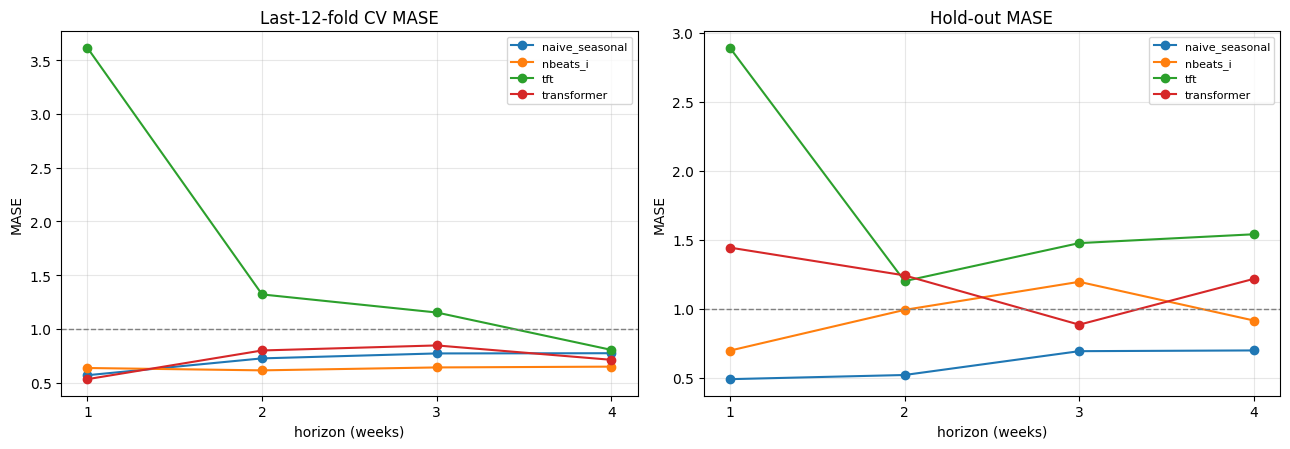

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, table, title in (
    (axes[0], attn_cv_with_naive, "Last-12-fold CV MASE"),
    (axes[1], pd.concat([attn_ho_table, ho_table[ho_table["model"] == "naive_seasonal"]], ignore_index=True),
     "Hold-out MASE"),
):
    order = ["naive_seasonal"] + ATTN_ORDER
    for name in order:
        sub = table[table["model"] == name]
        if sub.empty:
            continue
        ax.plot(sub["horizon"], sub["MASE"], marker="o", label=name)
    ax.axhline(1.0, color="grey", lw=1, ls="--")
    ax.set_xticks(HORIZONS)
    ax.set_xlabel("horizon (weeks)")
    ax.set_ylabel("MASE")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "attn_mase_by_horizon.png", dpi=130)
plt.show()


## 11. Interpretability

Fit the readable models on the **CV pool** (same information as hold-out) and
inspect what they actually use:

- Ridge coefficients on standardized features (h=1 estimator)
- XGBoost gain importance (h=1 estimator)
- DLinear trend vs seasonal linear weights (lag profile of the target)
- TFT variable-selection weights and temporal attention


Model supports multi-output; a single estimator forecasts all the horizons and components.


Model supports multi-output; a single estimator forecasts all the horizons and components.


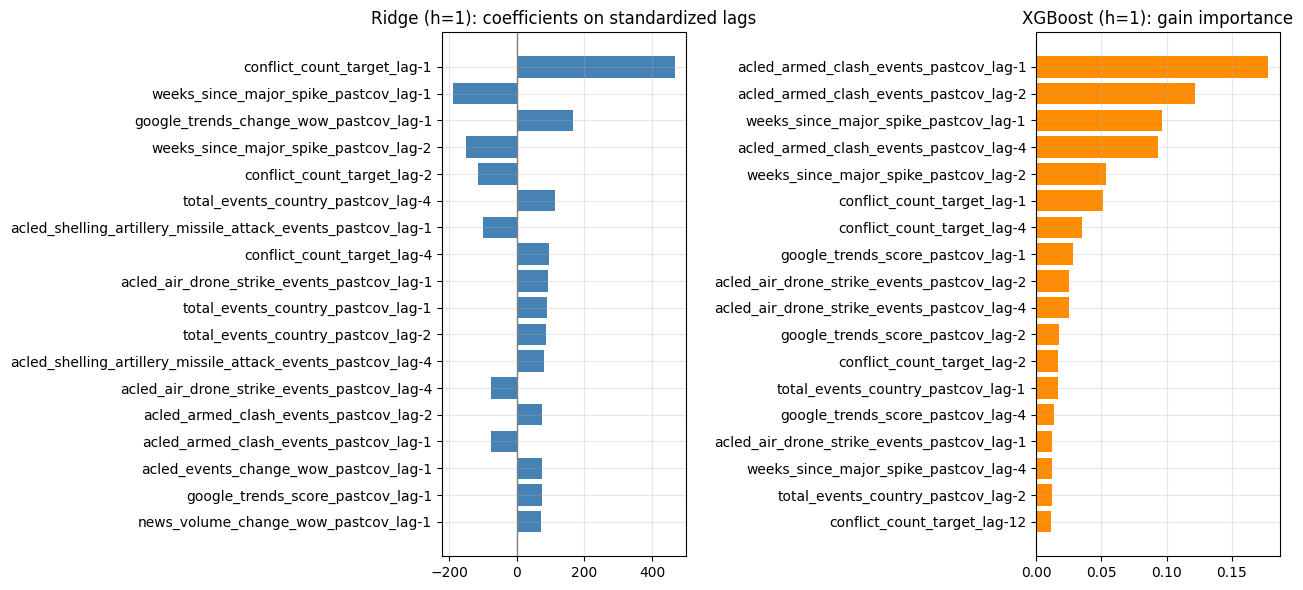

Ridge: largest |coef| are usually conflict_count lags; covariates should be small


,feature,weight,abs
3,conflict_count_target_lag-1,467.374,467.374
39,weeks_since_major_spike_pastcov_lag-1,-188.732,188.732
38,google_trends_change_wow_pastcov_lag-1,167.363,167.363
25,weeks_since_major_spike_pastcov_lag-2,-151.007,151.007
2,conflict_count_target_lag-2,-114.952,114.952
7,total_events_country_pastcov_lag-4,111.906,111.906
44,acled_shelling_artillery_missile_attack_events...,-98.916,98.916
1,conflict_count_target_lag-4,96.044,96.044
45,acled_air_drone_strike_events_pastcov_lag-1,93.205,93.205
35,total_events_country_pastcov_lag-1,89.654,89.654


XGBoost gain (h=1)


,feature,gain
43,acled_armed_clash_events_pastcov_lag-1,0.178
29,acled_armed_clash_events_pastcov_lag-2,0.121
39,weeks_since_major_spike_pastcov_lag-1,0.097
15,acled_armed_clash_events_pastcov_lag-4,0.094
25,weeks_since_major_spike_pastcov_lag-2,0.054
3,conflict_count_target_lag-1,0.051
1,conflict_count_target_lag-4,0.036
37,google_trends_score_pastcov_lag-1,0.029
31,acled_air_drone_strike_events_pastcov_lag-2,0.026
17,acled_air_drone_strike_events_pastcov_lag-4,0.025


In [24]:
def _coef_frame(model, horizon: int = 0) -> pd.DataFrame:
    names = list(model.lagged_feature_names or [])
    est = model.get_estimator(horizon=horizon, target_dim=0)
    if hasattr(est, "named_steps"):
        coef = np.asarray(est.named_steps["ridge"].coef_).ravel()
    elif hasattr(est, "coef_"):
        coef = np.asarray(est.coef_).ravel()
    elif hasattr(est, "feature_importances_"):
        coef = np.asarray(est.feature_importances_).ravel()
    else:
        raise TypeError(type(est))
    n = min(len(names), len(coef))
    return pd.DataFrame({"feature": names[:n], "weight": coef[:n]})


ridge_fi = _coef_frame(models_fast_ho["ridge"], horizon=0)
ridge_fi["abs"] = ridge_fi["weight"].abs()
ridge_top = ridge_fi.sort_values("abs", ascending=False).head(18)

xgb_fi = _coef_frame(models_fast_ho["xgb"], horizon=0).rename(columns={"weight": "gain"})
xgb_top = xgb_fi.sort_values("gain", ascending=False).head(18)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(ridge_top["feature"][::-1], ridge_top["weight"][::-1], color="steelblue")
axes[0].set_title("Ridge (h=1): coefficients on standardized lags")
axes[0].axvline(0, color="grey", lw=1)
axes[1].barh(xgb_top["feature"][::-1], xgb_top["gain"][::-1], color="darkorange")
axes[1].set_title("XGBoost (h=1): gain importance")
fig.tight_layout()
fig.savefig(FIG_DIR / "wave2_feature_importance.png", dpi=130)
plt.show()

print("Ridge: largest |coef| are usually conflict_count lags; covariates should be small")
display(ridge_top.round(3))
print("XGBoost gain (h=1)")
display(xgb_top.round(3))


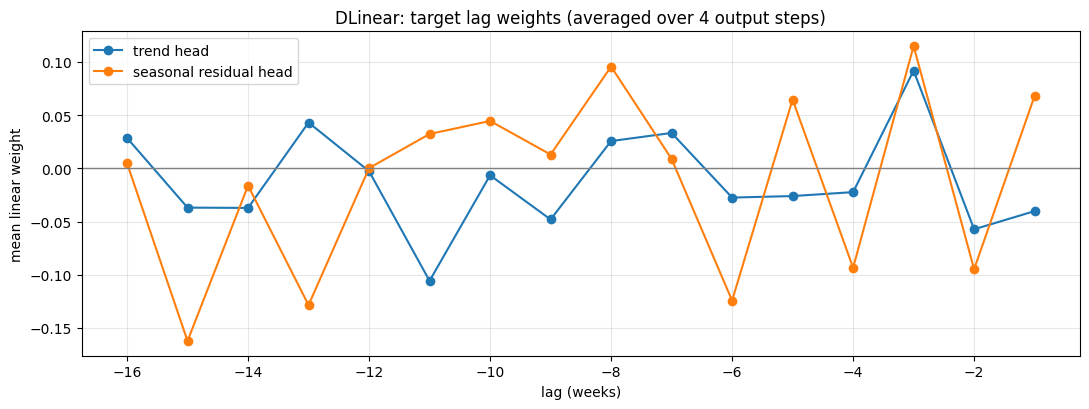

In [25]:
# DLinear lag profiles: trend and seasonal linear maps for the target channel.
# Mixed-covariates input is flattened as [target | past covs | historic future covs]
# with `input_chunk_length` weights per component.
dlin = models_fast_ho["dlinear"]
mod = dlin.model
trend_w = mod.linear_trend.weight.detach().cpu().numpy()
seas_w = mod.linear_seasonal.weight.detach().cpu().numpy()
icl = dlin.input_chunk_length


def _target_lag_profile(weight: np.ndarray, icl: int) -> np.ndarray:
    w = np.asarray(weight)
    if w.ndim == 1:
        w = w.reshape(1, -1)
    return w.mean(axis=0)[:icl]


lags = np.arange(-icl, 0)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(lags, _target_lag_profile(trend_w, icl), marker="o", label="trend head")
ax.plot(lags, _target_lag_profile(seas_w, icl), marker="o", label="seasonal residual head")
ax.axhline(0, color="grey", lw=1)
ax.set_xlabel("lag (weeks)")
ax.set_ylabel("mean linear weight")
ax.set_title("DLinear: target lag weights (averaged over 4 output steps)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "dlinear_lag_weights.png", dpi=130)
plt.show()


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


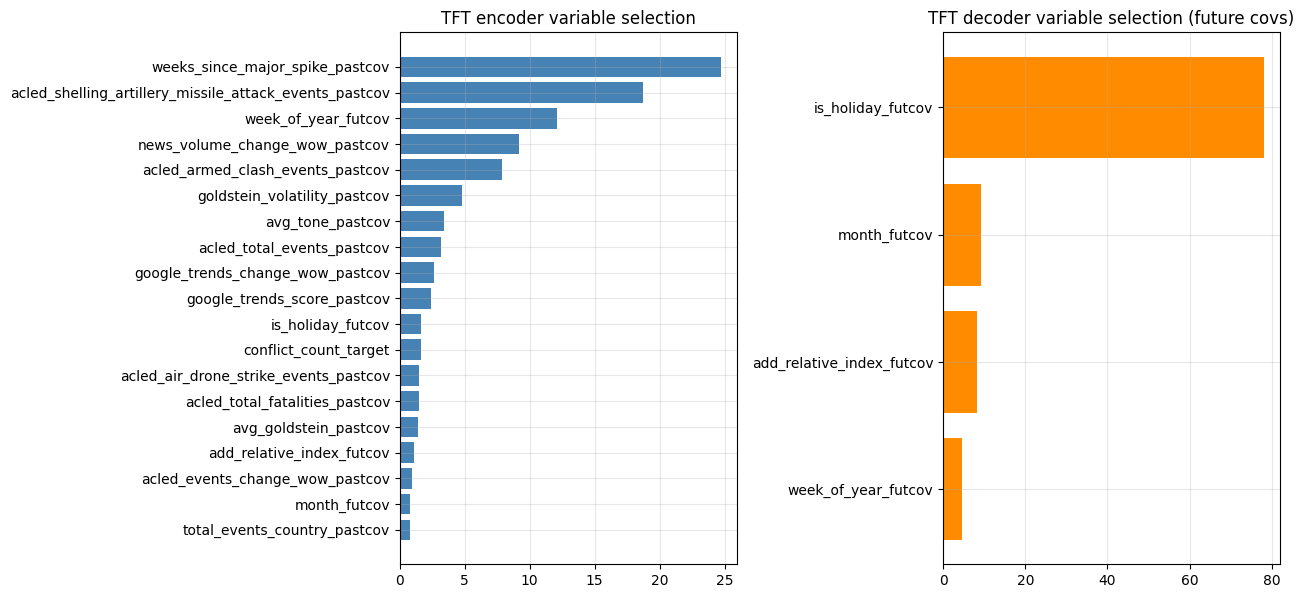

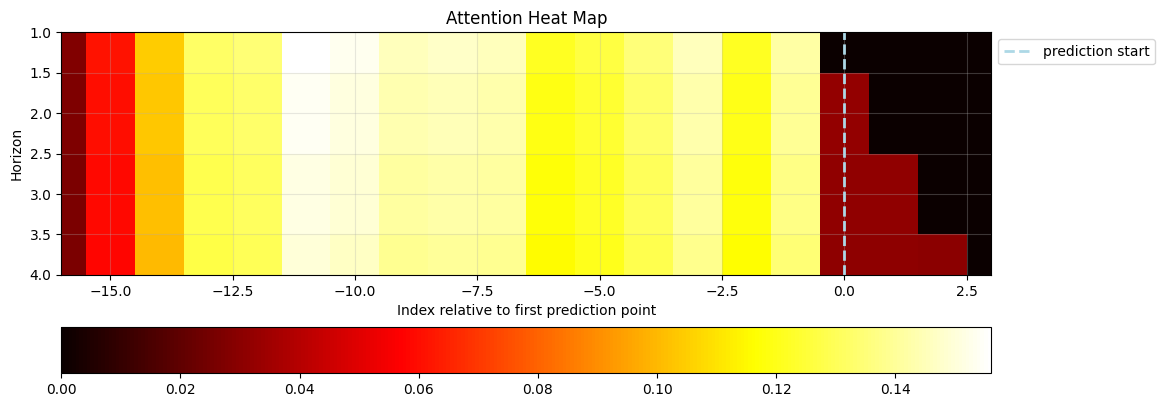

<Figure size 1200x450 with 0 Axes>

TFT encoder variable-selection weights


,0
weeks_since_major_spike_pastcov,24.7
acled_shelling_artillery_missile_attack_events_pastcov,18.7
week_of_year_futcov,12.1
news_volume_change_wow_pastcov,9.2
acled_armed_clash_events_pastcov,7.9
goldstein_volatility_pastcov,4.8
avg_tone_pastcov,3.4
acled_total_events_pastcov,3.2
google_trends_change_wow_pastcov,2.6
google_trends_score_pastcov,2.4


TFT decoder (future covariates) variable-selection weights


,0
is_holiday_futcov,78.1
month_futcov,9.2
add_relative_index_futcov,8.3
week_of_year_futcov,4.5


In [26]:
# TFT was fit on scaled series; Explainer defaults to the fit-time (scaled) background.
try:
    tft_explainer = TFTExplainer(models_attn_ho["tft"])
    tft_result = tft_explainer.explain()

    enc = tft_result.get_encoder_importance()
    dec = tft_result.get_decoder_importance()
    enc_s = enc.iloc[0].sort_values(ascending=True)
    dec_s = dec.iloc[0].sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, max(3.5, 0.32 * max(len(enc_s), 1))), sharex=False)
    axes[0].barh(enc_s.index, enc_s.values, color="steelblue")
    axes[0].set_title("TFT encoder variable selection")
    axes[1].barh(dec_s.index, dec_s.values, color="darkorange")
    axes[1].set_title("TFT decoder variable selection (future covs)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "tft_variable_selection.png", dpi=130)
    plt.show()

    tft_explainer.plot_attention(tft_result, plot_type="heatmap")
    plt.gcf().savefig(FIG_DIR / "tft_attention.png", dpi=130, bbox_inches="tight")
    plt.show()

    print("TFT encoder variable-selection weights")
    display(enc.T.sort_values(enc.T.columns[0], ascending=False).round(4))
    print("TFT decoder (future covariates) variable-selection weights")
    display(dec.T.sort_values(dec.T.columns[0], ascending=False).round(4))
except Exception as exc:
    print("TFT explainer failed:", exc)


## 12. Combined ranking

Hold-out is the only protocol on which **every** model is scored with the same
12 realized weeks. Full 44-fold CV ranks the readable models (wave 1 + Holt /
Kalman / Ridge / trees / DLinear / NLinear). Attention models have a separate
last-12-fold CV table so we do not mix `n=171` with `n≈48`.


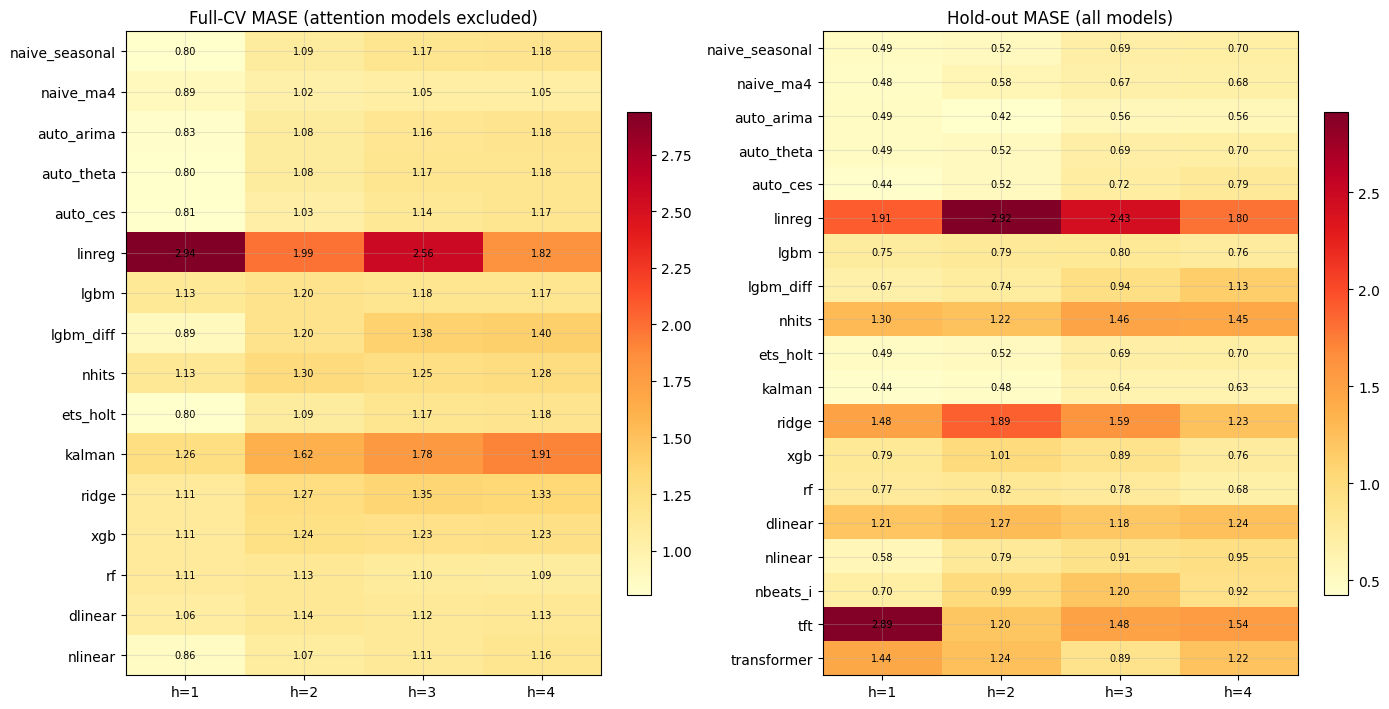

Hold-out ranking (mean MASE across h=1..4)


,mean_MASE,vs_naive_pct
model,,
auto_arima,0.509,15.302
kalman,0.545,9.226
auto_theta,0.599,0.241
ets_holt,0.601,0.000
naive_seasonal,0.601,0.000
naive_ma4,0.604,-0.543
auto_ces,0.618,-2.950
rf,0.764,-27.243
lgbm,0.775,-29.019


Full-CV ranking (mean MASE across h=1..4)


,mean_MASE,vs_naive_pct
model,,
naive_ma4,1.003,5.430
auto_ces,1.036,2.338
nlinear,1.052,0.825
auto_theta,1.059,0.166
ets_holt,1.060,0.000
naive_seasonal,1.060,0.000
auto_arima,1.061,-0.022
rf,1.107,-4.369
dlinear,1.113,-4.969


In [27]:
# Prefer in-memory wave-1 tables; fall back to metrics.json if this section is re-run alone.
if "cv_table" not in globals() or cv_table is None or cv_table.empty:
    raw_m = pd.read_json(OUT_DIR / "metrics.json")
    raise RuntimeError("cv_table missing — run wave-1 cells first")

cv_all = pd.concat([cv_table, fast_cv_table], ignore_index=True)
ho_all = pd.concat([ho_table, fast_ho_table, attn_ho_table], ignore_index=True)
cv_all = add_vs_baseline(cv_all.drop(columns=["vs_naive_pct"], errors="ignore"))
ho_all = add_vs_baseline(ho_all.drop(columns=["vs_naive_pct"], errors="ignore"))

ALL_CV_MODELS = MODEL_ORDER + FAST_ORDER
ALL_HO_MODELS = MODEL_ORDER + FAST_ORDER + ATTN_ORDER


def _pivot_mase(table, models):
    mat = table.pivot(index="model", columns="horizon", values="MASE")
    return mat.reindex([m for m in models if m in mat.index])


cv_mat = _pivot_mase(cv_all, ALL_CV_MODELS)
ho_mat = _pivot_mase(ho_all, ALL_HO_MODELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.2))
for ax, mat, title in (
    (axes[0], cv_mat, "Full-CV MASE (attention models excluded)"),
    (axes[1], ho_mat, "Hold-out MASE (all models)"),
):
    im = ax.imshow(mat.to_numpy(), aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(mat.columns)), [f"h={c}" for c in mat.columns])
    ax.set_yticks(range(len(mat.index)), list(mat.index))
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.to_numpy()[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(FIG_DIR / "combined_mase_heatmaps.png", dpi=130)
plt.show()

print("Hold-out ranking (mean MASE across h=1..4)")
ho_rank = (
    ho_all.groupby("model")["MASE"].mean()
    .reindex(ALL_HO_MODELS)
    .dropna()
    .sort_values()
    .to_frame("mean_MASE")
)
ho_rank["vs_naive_pct"] = (
    (ho_rank.loc["naive_seasonal", "mean_MASE"] - ho_rank["mean_MASE"])
    / ho_rank.loc["naive_seasonal", "mean_MASE"] * 100
)
display(ho_rank.round(3))

print("Full-CV ranking (mean MASE across h=1..4)")
cv_rank = (
    cv_all.groupby("model")["MASE"].mean()
    .reindex(ALL_CV_MODELS)
    .dropna()
    .sort_values()
    .to_frame("mean_MASE")
)
cv_rank["vs_naive_pct"] = (
    (cv_rank.loc["naive_seasonal", "mean_MASE"] - cv_rank["mean_MASE"])
    / cv_rank.loc["naive_seasonal", "mean_MASE"] * 100
)
display(cv_rank.round(3))


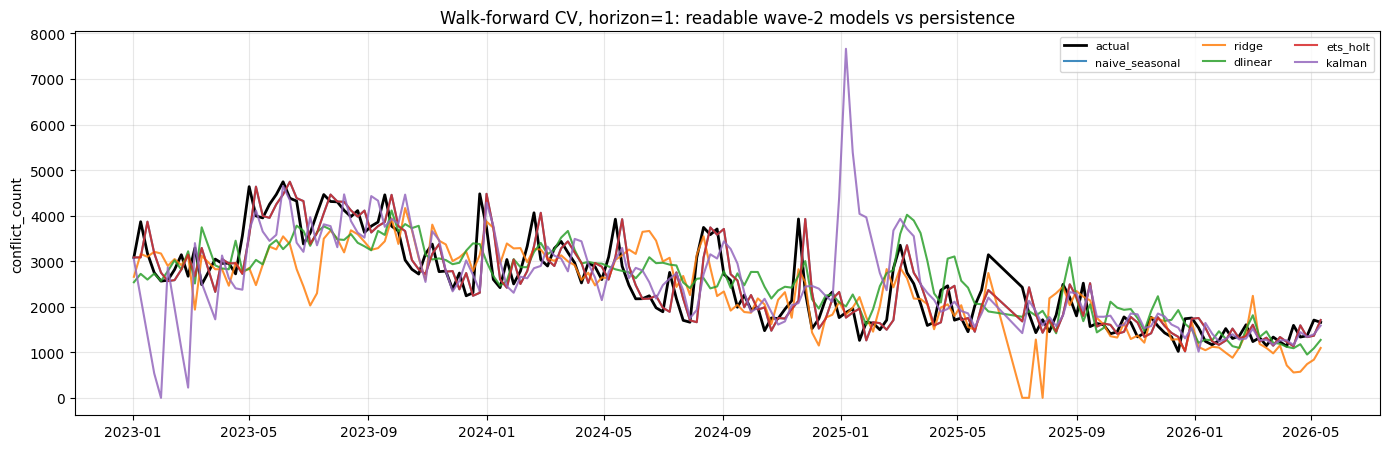

In [28]:
# Stitched h=1: wave-1 naive vs the most readable wave-2 challengers
h1_fast = fast_cv_df[fast_cv_df["horizon"] == 1]
h1_orig = cv_df[cv_df["horizon"] == 1]
fig, ax = plt.subplots(figsize=(14, 4.6))
actual = h1_orig[h1_orig["model"] == "naive_seasonal"].sort_values("week")
ax.plot(actual["week"], actual["y_true"], color="black", lw=2, label="actual")
for name, src in [
    ("naive_seasonal", h1_orig),
    ("ridge", h1_fast),
    ("dlinear", h1_fast),
    ("ets_holt", h1_fast),
    ("kalman", h1_fast),
]:
    sub = src[src["model"] == name].sort_values("week")
    ax.plot(sub["week"], sub["y_pred"], alpha=0.85, label=name)
ax.set_title("Walk-forward CV, horizon=1: readable wave-2 models vs persistence")
ax.set_ylabel("conflict_count")
ax.legend(fontsize=8, ncols=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "wave2_cv_stitched_h1.png", dpi=130)
plt.show()


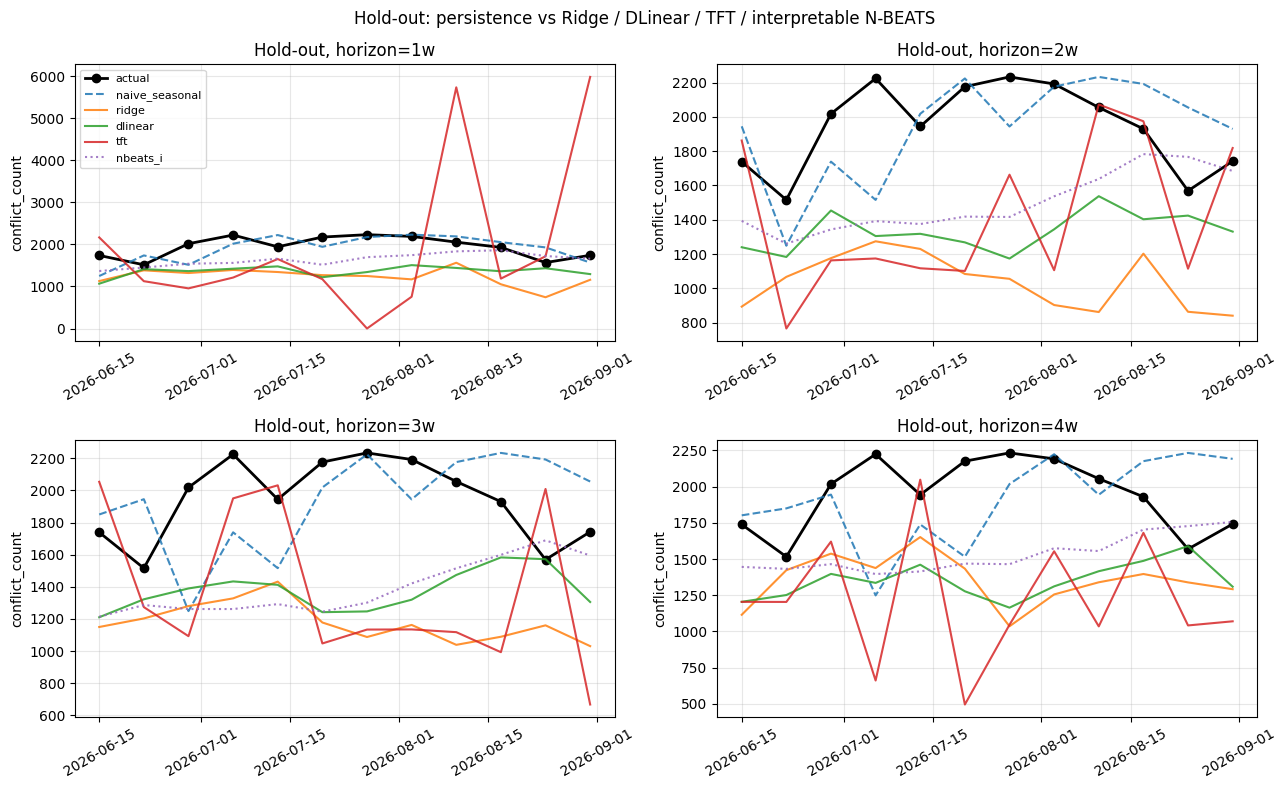

In [29]:
# Hold-out actual vs predicted including TFT / DLinear / Ridge
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
plot_models = [
    ("naive_seasonal", ho_df, "--"),
    ("ridge", fast_ho_df, "-"),
    ("dlinear", fast_ho_df, "-"),
    ("tft", attn_ho_df, "-"),
    ("nbeats_i", attn_ho_df, ":"),
]
for ax, h in zip(axes.flat, HORIZONS):
    actual = ho_df[(ho_df["horizon"] == h) & (ho_df["model"] == "naive_seasonal")].sort_values("week")
    ax.plot(actual["week"], actual["y_true"], "o-", color="black", lw=2, label="actual")
    for name, src, style in plot_models:
        m = src[(src["horizon"] == h) & (src["model"] == name)].sort_values("week")
        if m.empty:
            continue
        ax.plot(m["week"], m["y_pred"], style, label=name, alpha=0.85)
    ax.set_title(f"Hold-out, horizon={h}w")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("conflict_count")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Hold-out: persistence vs Ridge / DLinear / TFT / interpretable N-BEATS")
fig.tight_layout()
fig.savefig(FIG_DIR / "wave2_holdout_actual_vs_predicted.png", dpi=130)
plt.show()


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


`Trainer.fit` stopped: `max_epochs=40` reached.


GPU available: False, used: False


...

TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


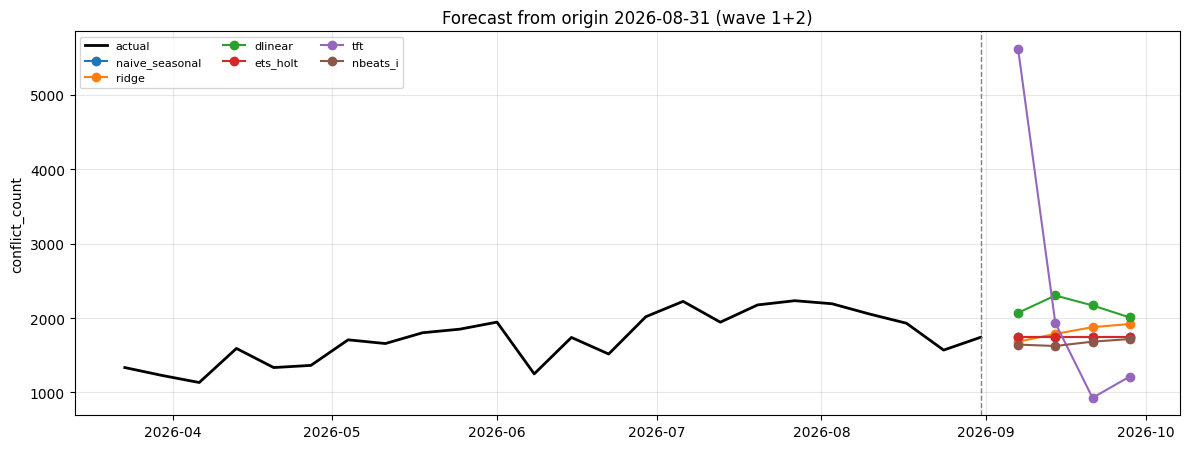

,country,origin_week,target_week,horizon_weeks,naive_seasonal,naive_ma4,auto_arima,auto_theta,auto_ces,linreg,...,ets_holt,kalman,ridge,xgb,rf,dlinear,nlinear,nbeats_i,tft,transformer
0,Ukraine,2026-08-31,2026-09-07,1,1742.0,1824.0,1696.9,1740.3,1686.4,1691.4,...,1742.0,1836.6,1682.6,1855.6,1916.8,2070.0,1927.0,1642.6,5620.2,1692.6
1,Ukraine,2026-08-31,2026-09-14,2,1742.0,1766.2,1608.3,1740.3,1621.1,1917.8,...,1742.0,1868.6,1786.3,1877.1,1938.8,2303.1,2043.5,1623.9,1934.0,1499.9
2,Ukraine,2026-08-31,2026-09-21,3,1742.0,1725.3,1525.7,1740.3,1595.6,1844.0,...,1742.0,1904.3,1877.1,1893.7,1941.1,2169.3,2080.3,1682.4,927.0,1600.7
3,Ukraine,2026-08-31,2026-09-28,4,1742.0,1764.4,1459.3,1740.3,1541.3,1781.3,...,1742.0,1939.8,1919.5,2011.7,1926.5,2007.8,1913.8,1717.0,1213.5,1725.5


In [30]:
# Future 1–4 week forecast from the last complete week, including wave-2 models
models_fast_full = make_fast_models(SEED)
fit_fast_on_prefix(models_fast_full, last_idx)
fast_future = predict_fast_origin(models_fast_full, last_idx)

models_attn_full = make_attn_models(SEED)
scalers_attn_full = fit_attn_on_prefix(models_attn_full, last_idx)
attn_future = predict_attn_origin(models_attn_full, scalers_attn_full, last_idx)

for name in FAST_ORDER:
    forecast_df[name] = [round(float(fast_future[name][h - 1]), 1) for h in HORIZONS]
for name in ATTN_ORDER:
    forecast_df[name] = [round(float(attn_future[name][h - 1]), 1) for h in HORIZONS]
forecast_df.to_csv(OUT_DIR / "forecast.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 4.6))
hist = raw.tail(24)
ax.plot(hist["week_start"], hist["conflict_count"], color="black", lw=2, label="actual")
show = ["naive_seasonal", "ridge", "dlinear", "ets_holt", "tft", "nbeats_i"]
for name in show:
    if name in future_preds:
        vals = [future_preds[name][h - 1] for h in HORIZONS]
    elif name in fast_future:
        vals = [fast_future[name][h - 1] for h in HORIZONS]
    else:
        vals = [attn_future[name][h - 1] for h in HORIZONS]
    ax.plot(forecast_weeks, vals, marker="o", label=name)
ax.axvline(last_week, color="grey", ls="--", lw=1)
ax.set_title(f"Forecast from origin {last_week.date()} (wave 1+2)")
ax.set_ylabel("conflict_count")
ax.legend(fontsize=8, ncols=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "future_forecast_wave2.png", dpi=130)
plt.show()
forecast_df


In [31]:
def _metrics_block(table: pd.DataFrame) -> dict:
    return {
        str(h): {
            row["model"]: {
                k: float(row[k]) if k != "model" else row[k]
                for k in ["MASE", "sMAPE", "RMSE", "MAE", "n", "vs_naive_pct"]
            }
            for row in table[table["horizon"] == h].to_dict(orient="records")
        }
        for h in HORIZONS
    }


metrics_out = {
    "cv": _metrics_block(cv_all),
    "holdout": _metrics_block(ho_all),
    "cv_attention_last12": _metrics_block(attn_cv_with_naive),
    "n_cv_folds": int(n_folds),
    "n_attention_cv_folds": int(len(RECENT_FOLDS)),
    "holdout_start": str(holdout_start),
    "models": ALL_HO_MODELS,
    "models_full_cv": ALL_CV_MODELS,
    "models_attention": ATTN_ORDER,
}
write_json(OUT_DIR / "metrics.json", metrics_out)
write_json(OUT_DIR / "metrics_wave2.json", {
    "cv_fast": _metrics_block(fast_cv_table),
    "holdout_fast": _metrics_block(fast_ho_table),
    "cv_attention_last12": _metrics_block(attn_cv_with_naive),
    "holdout_attention": _metrics_block(attn_ho_table),
})

print("Best full-CV model per horizon (wave 1+2 readable set):")
display(
    cv_all.loc[cv_all.groupby("horizon")["MASE"].idxmin(), ["horizon", "model", "MASE", "vs_naive_pct"]].round(3)
)
print("Best hold-out model per horizon (all models):")
display(
    ho_all.loc[ho_all.groupby("horizon")["MASE"].idxmin(), ["horizon", "model", "MASE", "vs_naive_pct"]].round(3)
)
print(f"Wrote {OUT_DIR / 'metrics.json'} and {OUT_DIR / 'metrics_wave2.json'}")
print(f"Figures in {FIG_DIR}")


Best full-CV model per horizon (wave 1+2 readable set):


,horizon,model,MASE,vs_naive_pct
0,1,auto_theta,0.803,0.092
9,2,naive_ma4,1.018,6.340
18,3,naive_ma4,1.053,9.928
27,4,naive_ma4,1.048,11.258


Best hold-out model per horizon (all models):


,horizon,model,MASE,vs_naive_pct
36,1,kalman,0.436,11.030
9,2,auto_arima,0.424,18.510
18,3,auto_arima,0.556,19.742
27,4,auto_arima,0.564,19.190


Wrote /home/romanrussia/Code_git/GDETL/outputs/darts/metrics.json and /home/romanrussia/Code_git/GDETL/outputs/darts/metrics_wave2.json
Figures in /home/romanrussia/Code_git/GDETL/outputs/darts/figures


## 13. Takeaways (wave 2)

**More sophisticated did not beat a readable baseline.** On this near-unit-root
weekly conflict series the models worth deploying are still `naive_ma4`
(full CV) and `AutoARIMA` (hold-out). Transformer-class models are not
justified at ~245 weekly points.

**Full 44-fold CV (mean MASE across h=1..4, n=171)** — the ranking to trust:

| Rank | Model | Mean MASE | vs naive |
|---|---|---|---|
| 1 | `naive_ma4` | 1.003 | **+5.4%** |
| 2 | `auto_ces` | 1.036 | +2.3% |
| 3 | `nlinear` | 1.052 | +0.8% |
| 4 | `auto_theta` / damped Holt / naive | 1.06 | ~0 |
| … | Ridge (scaled) | 1.265 | −19% |
| … | unregularized `linreg` | 2.329 | −120% |
| last readable | Kalman | 1.643 | −55% |

- **NLinear** is the only neural net that belongs in the conversation: last-value
  normalization + a linear map, mean MASE 1.052. It still loses to a 4-week MA.
  DLinear is a bit worse (1.113).
- **Damped Holt** (`ets_holt`) ties persistence — confirming that wave-1 ETS
  failed because of a forced 52-week season, not because exponential smoothing
  is the wrong family.
- **Ridge vs linreg:** scaling + L2 turns a disaster (MASE 2.33) into a merely
  mediocre linear model (1.27). Coefficients are dominated by `conflict_count`
  lag-1, as they should be on a unit-root series; extra GDELT/ACLED lags add
  noise rather than signal. Regularization was necessary, not sufficient.
- **Shallow RF / XGB** still lose to naive on CV. XGB *does* use ACLED armed-clash
  lags (top gain), but that does not translate into beating “next week ≈ this week”.

**Hold-out (n=12, noisy):** `auto_arima` still wins (mean MASE 0.509, **+15%**).
Kalman looks good here (0.545) and terrible on CV (1.643) — treat the hold-out
Kalman number as a small-sample fluke, not a reason to ship a state-space model.
TFT is the worst neural model (mean MASE 1.78); interpretable N-BEATS is 0.95.

**Last-12-fold CV for attention models** (same recent window, vs persistence):

- Interpretable **N-BEATS** beats naive at h=2/3/4 by **+15% to +17%**, and loses
  at h=1. Hold-out does **not** confirm the win.
- **Transformer** nicks naive at h=1 (+6.5%) and loses on hold-out (mean MASE 1.20).
- **TFT collapses** (h=1 MASE 3.61, **−534%** vs naive). The variable-selection
  plot explains why: encoder weight on `conflict_count` is ~1.6%, while
  `weeks_since_major_spike` (25%) and ACLED shelling (19%) dominate; the decoder
  puts **78%** on `is_holiday`. The attention block never learned persistence.

**What to take to the assignment write-up**

1. Prefer **interpretable statistical models** (`naive_ma4`, AutoTheta, AutoARIMA,
   damped Holt). They match the information set and do not overfit 245 weeks.
2. If a neural model is required, use **NLinear** (or DLinear) — few parameters,
   readable lag weights — not TFT / Transformer / N-HiTS.
3. TFT is still useful as a *diagnostic*: its selection weights show the model
   ignoring the lag-1 target, which is exactly how a transformer fails here.

New artifacts: `outputs/darts/metrics_wave2.json`, `outputs/darts/forecast.csv`
(now includes wave-2 columns), and `outputs/darts/figures/`
(`wave2_*`, `attn_*`, `tft_variable_selection.png`, `dlinear_lag_weights.png`,
`combined_mase_heatmaps.png`).
